# Run this first !
Ensures correct libraries and imports data

In [108]:
# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

# Updated with new data as of 2026-09-30
utt = loading.load(DATA, "all_utterances.csv", "2026-09-30")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-30")
met = loading.load(DATA, "all_metrics.csv", "2026-09-30")

print(utt.shape, sent.shape, met.shape)
sent.head()
#data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23', '2026-09-30']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows
(2570, 11) (19092, 12) (1021, 6)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,1,"Good morning, ladies and gentlemen."
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,3,This call is being recorded.
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,4,Your line will be muted for the duration of th...
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,5,We will now go live to the presentation.


In [109]:
# Start timer
import time
start_time = time.time()

# Using John's changes to the exported data

## Link to download data will need to change

In [110]:
# Import structured sentences file
str_sent = pd.read_csv("/Users/rdrobinson/Cambridge/boe-financial-analysis/notebooks/rachel/All_in_one/revised_structured_sentences.csv")
data = str_sent.copy()

In [111]:
# Remove rows where is_filler_sentence = True
data = data[data['is_filler_sentence'] != True]

In [112]:
data.head()

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...,0,Welcome to JPMorgan Chase's First Quarter 2022...,False
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,3,This call is being recorded.,0,This call is being recorded.,False
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,4,Your line will be muted for the duration of th...,0,Your line will be muted for the duration of th...,False
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,5,We will now go live to the presentation.,0,We will now go live to the presentation.,False
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,7,"At this time, I would like to turn the call ov...",0,"At this time, I would like to turn the call ov...",False


# Sentence tokenisation

### Import ntlk

In [113]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Speaker Names
Need to remove these from the sentences

In [114]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

[['joseph', 'dickerson'],
 ['scott', 'siefers'],
 ['christopher', 'mcgratty'],
 ['piers', 'brown'],
 ['ebrahim', 'h.', 'poonawala'],
 ['stefan', 'stalmann'],
 ['glenn', 'schorr'],
 ['matt', "o'connor"],
 ['jon', 'peace'],
 ['sergio', 'p.', 'ermotti']]

### Tokenising Function

In [115]:
import re

def expand_contractions(t):
    t = t.replace("’", "'")
    t = re.sub(r"won't", "will not", t)
    t = re.sub(r"can't", "can not", t)
    t = re.sub(r"n't\b", " not", t)
    t = re.sub(r"'(s|re|ve|ll|d|m)\b", "", t)
    return t


In [116]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    #text = re.sub(r'[^a-zA-Z\s]', '', text)
    # in preprocess_text, after text = text.lower():
    text = expand_contractions(text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        # Removed "greeting words" from the line below:
        if word not in stop_words and word.isalpha() and word and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [117]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(5))

                                            sentence  \
1  Welcome to JPMorgan Chase's First Quarter 2022...   
2                       This call is being recorded.   
3  Your line will be muted for the duration of th...   
4           We will now go live to the presentation.   
6  At this time, I would like to turn the call ov...   

                                        cleaned_text  
1  [welcome, jpmorgan, chase, first, quarter, ear...  
2                                   [call, recorded]  
3                      [line, muted, duration, call]  
4                           [go, live, presentation]  
6  [time, would, like, turn, call, jpmorgan, chas...  


In [118]:
# Count number of rows for total sentences
print("The total number of sentences for both banks is:", data.shape[0])


The total number of sentences for both banks is: 16513


# Choose Bank
Amend the commented section to include the bank of choice. Default is set as UBS

In [119]:
# Choose bank name - either UBS or JPM for this work
bank_name = 'JPM'

In [120]:
# Create folder for bank_name specific sentiment classification results
import os

results_folder = f"results_{bank_name}"
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

In [121]:
# Create dataframe with bank = '***' (replace with bank of choice)
data = data[data['bank'] == bank_name].copy()
print(data.shape)
data.head(2)

(8296, 16)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence,cleaned_text
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...,0,Welcome to JPMorgan Chase's First Quarter 2022...,False,"[welcome, jpmorgan, chase, first, quarter, ear..."
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,3,This call is being recorded.,0,This call is being recorded.,False,"[call, recorded]"


In [122]:
# Count number of rows for total sentences for chosen bank
print(f"The total number of sentences for {bank_name} is:", data.shape[0])

The total number of sentences for JPM is: 8296


<Figure size 1000x600 with 0 Axes>

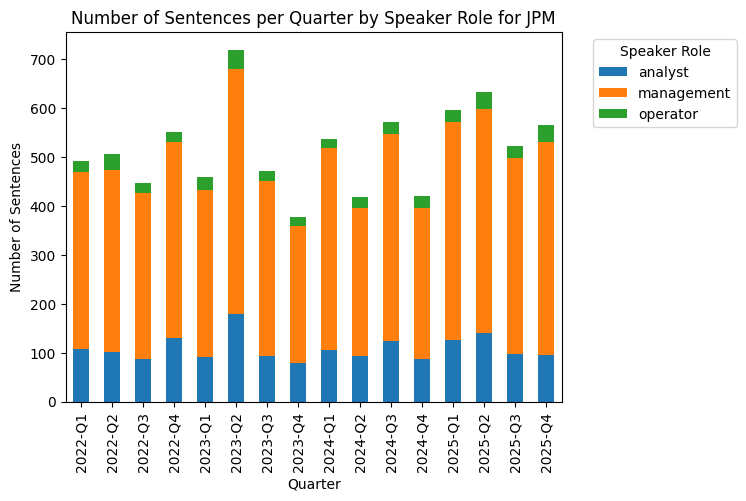

In [123]:
# Plot number of sentences for each quarter, split by speaker_role as a stacked plot
# This plot shows the distribution of sentences per quarter, broken down by speaker role.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
data.groupby(['quarter', 'speaker_role'])['sentence'].count().unstack().plot(kind='bar', stacked=True)
# Include bank name in the title
plt.title(f'Number of Sentences per Quarter by Speaker Role for {bank_name}')
plt.xlabel('Quarter')
plt.ylabel('Number of Sentences')
# Move legend outside the plot
plt.legend(title='Speaker Role', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



Note the call date for Q4 2022 was in January 2023, and also the Q1 2023 call date was in April 2023, after the announcement to acquire Credit Suisse on the 19th March 2023.

## Split by Section to check speakers
Are the same speakers who give the presentation, the same as those who are involved in the Q&A. If so then their language can be directly compared in both

In [124]:
# List all speaker names that are speaker_role = management and section = 'Q&A'
management_qa_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'qa')]['speaker_name'].unique()
print(management_qa_speakers)

['Jeremy Barnum' 'Jamie Dimon']


In [125]:
# List all speaker names that are speaker_role = management and section = "prepared"
management_prepared_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'prepared')]['speaker_name'].unique()
print(management_prepared_speakers)

['Jeremy Barnum' 'Jamie Dimon']


All of the speakers listed as Management in the Q&A session match those in the presentation section and therefore their responses during a scripted presentation vs an open Q&A session can be investigated.

# Bert Emotion: All sections

Truncation = True means only 512 tokens (350 -400 words) are kept. Anything longer is ignored. Also output contains top_k = None so that the scores for all the emotions are retained to allow comparison later on

## Fix colours for emotions

In [126]:
# Fix colours of bars to emotion categories to be used in sns and matplotlib
emotion_palette = {
    'joy': 'darkorange',
    'anger': 'red',
    'sadness': 'dodgerblue',
    'fear': 'purple',
    'surprise': 'green',
    'disgust': 'brown',
    'love': 'deeppink'
}

## Build pipeline

In [127]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    data["sentence"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7795.31it/s]


## Run the model

In [128]:
# Run the model and keep all emotion scores
basic_emotion = emotion_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
emotion_rows = []
for result in basic_emotion:
    if isinstance(result, list):
        emotion_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        emotion_rows.append({result["label"]: result["score"]})
    else:
        emotion_rows.append({})

# Add the top emotion and score to the dataframe
data["main_emotion"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in emotion_rows
]
data["main_emotion_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in emotion_rows
]

# Add all emotion columns as separate numeric columns
for emotion in ["anger", "joy", "fear", "sadness", "love", "surprise"]:
    data[emotion] = [row.get(emotion, 0.0) for row in emotion_rows]

In [129]:
data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,is_filler_sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,False,"[welcome, jpmorgan, chase, first, quarter, ear...",joy,0.997568,0.000354,0.997568,0.000188,0.001008,0.000504,0.000378
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,False,"[call, recorded]",fear,0.477622,0.349039,0.147977,0.477622,0.011760,0.005599,0.008003


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

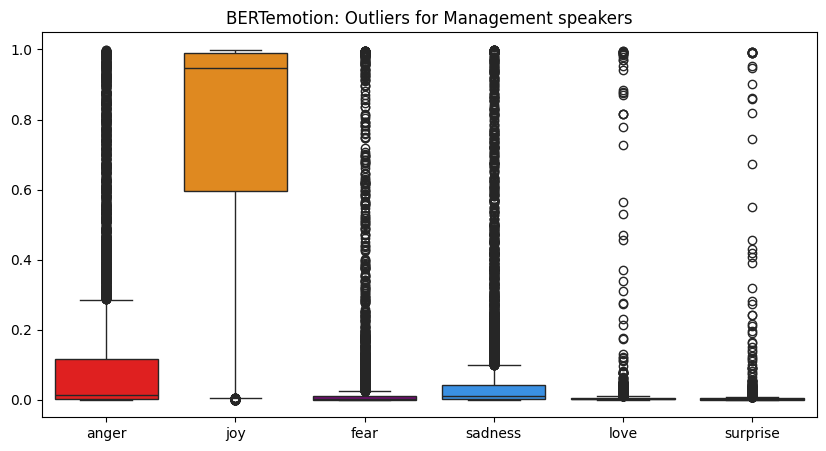

In [130]:
# Look for outliers in emotions of ubs_data where speaker_role = "management"
import seaborn as sns

# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -6:], palette=emotion_palette)
plt.title("BERTemotion: Outliers for Management speakers")
plt.show()

## Calculate quarterly emotion values (Management not Analyst)

In [131]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS)
emotion_stats = data.groupby(["quarter", "main_emotion", "speaker_role","section"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
emotion_stats = emotion_stats[emotion_stats['speaker_role'] != 'analyst']
emotion_stats.head(10)   

,quarter,main_emotion,speaker_role,section,median_score,std_score
1,2022-Q1,anger,management,prepared,0.650426,0.183977
2,2022-Q1,anger,management,qa,0.738492,0.185196
3,2022-Q1,anger,operator,prepared,0.613427,0.000000
4,2022-Q1,anger,operator,qa,0.913629,0.190759
6,2022-Q1,fear,management,prepared,0.718472,0.391487
7,2022-Q1,fear,management,qa,0.927592,0.229005
8,2022-Q1,fear,operator,prepared,0.477622,0.000000
10,2022-Q1,joy,management,prepared,0.944344,0.133544
11,2022-Q1,joy,management,qa,0.969360,0.149661
12,2022-Q1,joy,operator,prepared,0.986460,0.016821


In [132]:
# Calculate max and mean values for std_score
emotion_std_max = emotion_stats.groupby('main_emotion')['std_score'].max()
emotion_std_mean = emotion_stats.groupby('main_emotion')['std_score'].mean()
print("Max std_score per emotion:")
print(emotion_std_max)
print("\nMean std_score per emotion:")
print(emotion_std_mean)

Max std_score per emotion:
main_emotion
anger       0.245794
fear        0.391487
joy         0.218827
love        0.299286
sadness     0.311359
surprise    0.366685
Name: std_score, dtype: float64

Mean std_score per emotion:
main_emotion
anger       0.113554
fear        0.102330
joy         0.097446
love        0.044403
sadness     0.168173
surprise    0.116775
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections for all emotions

In [133]:
# Calculate differences between prepared and QA emotion scores for UBS management if NaN use zero
diff_emotion_stats = emotion_stats.pivot_table(index=['quarter', 'main_emotion'], columns='section', values='median_score').reset_index()
diff_emotion_stats = diff_emotion_stats.fillna(0)
diff_emotion_stats['diff'] = diff_emotion_stats['qa'] - diff_emotion_stats['prepared']

In [134]:
# Find max standard deviation from all emotions from emotion_std_max values
all_emotion_std_max = emotion_std_max.max()
print("Value for error bars: ", all_emotion_std_max)

Value for error bars:  0.391486924025655


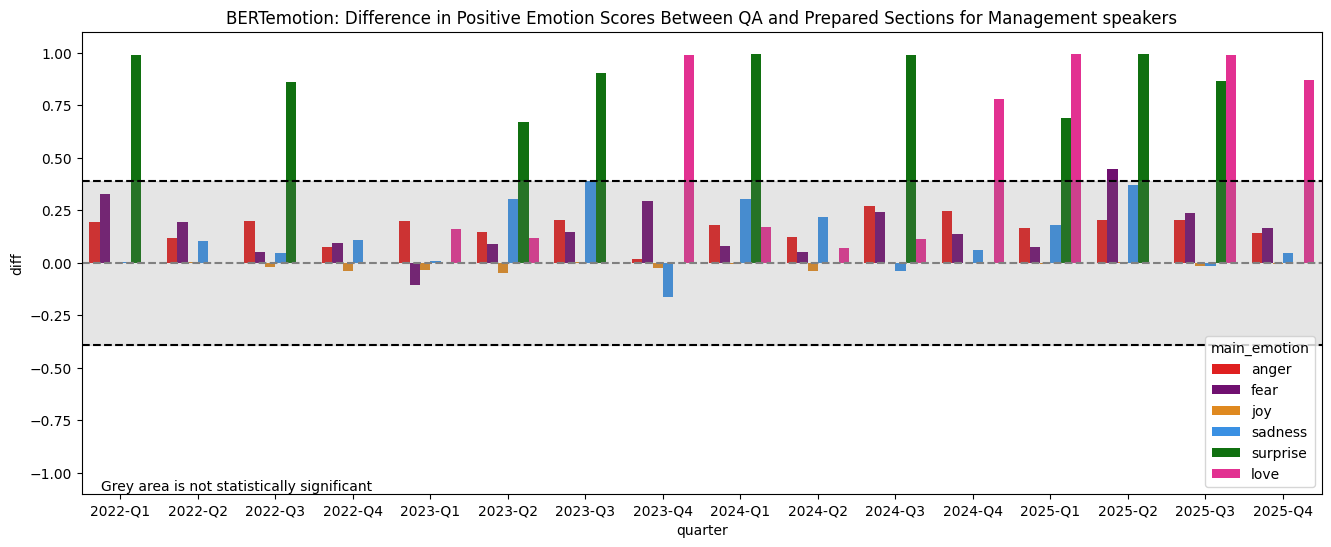

In [135]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=-1.1, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/BERT_emotion_differences_{bank_name}.png")

### Merger period Q2 2022 to Q2 2024

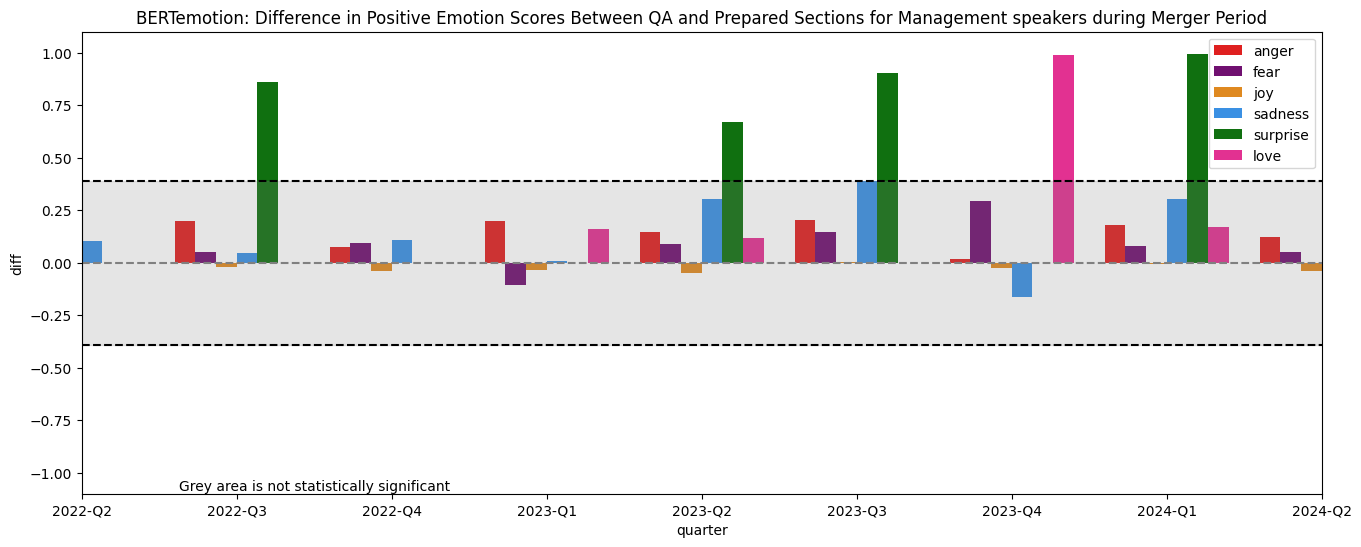

In [136]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

#Set x-lim to include from 2022-Q2 to 2024-Q2
plt.xlim("2022-Q2", "2024-Q2")
# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

# move legend to upper right
plt.legend(loc='upper right')
plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers during Merger Period")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=2.5, 
    y=-1.1, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/BERT_emotion_differences_merge_period_{bank_name}.png")

# FinBERT Model

## Fix colours for sentiments

In [137]:
# Fix colours of bars to sentiment categories to be used in sns and matplotlib
sentiment_palette = {
    # For FinBERT model
    'positive': 'darkorange',
    'neutral': 'grey',
    'negative': 'dodgerblue',

    # For FinBERT-Tone model
    'Positive': 'darkorange',
    'Neutral': 'grey',
    'Negative': 'dodgerblue',

    # For FinBERT-Tone model (which also uses capitalized sentiment labels)
    'FBT_Positive': 'darkorange',
    'FBT_Neutral': 'grey',
    'FBT_Negative': 'dodgerblue',

    # For RoBERTa model
    'RBT_positive': 'darkorange',
    'RBT_neutral': 'grey',
    'RBT_negative': 'dodgerblue',
}

## Build pipeline

In [138]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "prosusai/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["sentence"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 56489.89it/s]


## Run the model

In [139]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["main_sentiment"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in sentiment_rows
]
data["main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["positive", "negative", "neutral"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [140]:

data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,joy,fear,sadness,love,surprise,main_sentiment,main_sentiment_score,positive,negative,neutral
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,0.997568,0.000188,0.001008,0.000504,0.000378,neutral,0.879463,0.107888,0.012649,0.879463
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,0.147977,0.477622,0.011760,0.005599,0.008003,neutral,0.940165,0.023411,0.036424,0.940165
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,0.005777,0.345114,0.027400,0.003342,0.004941,neutral,0.913674,0.028846,0.057481,0.913674
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,0.989173,0.000778,0.001802,0.001674,0.000781,neutral,0.945190,0.040750,0.014060,0.945190
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,0.958501,0.003580,0.005817,0.005675,0.001442,neutral,0.943921,0.040531,0.015547,0.943921
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,0.983748,0.002539,0.003842,0.003369,0.000668,neutral,0.928419,0.049427,0.022154,0.928419
10,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,0.433808,0.014542,0.015374,0.020932,0.003248,neutral,0.952012,0.022636,0.025351,0.952012
11,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38079,...,0.990668,0.000986,0.004726,0.001048,0.001158,neutral,0.898367,0.085675,0.015957,0.898367
12,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38080,...,0.827415,0.006055,0.145707,0.002341,0.001632,negative,0.807250,0.020629,0.807250,0.172121
13,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38081,...,0.998795,0.000098,0.000311,0.000418,0.000210,positive,0.957459,0.957459,0.018213,0.024328


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

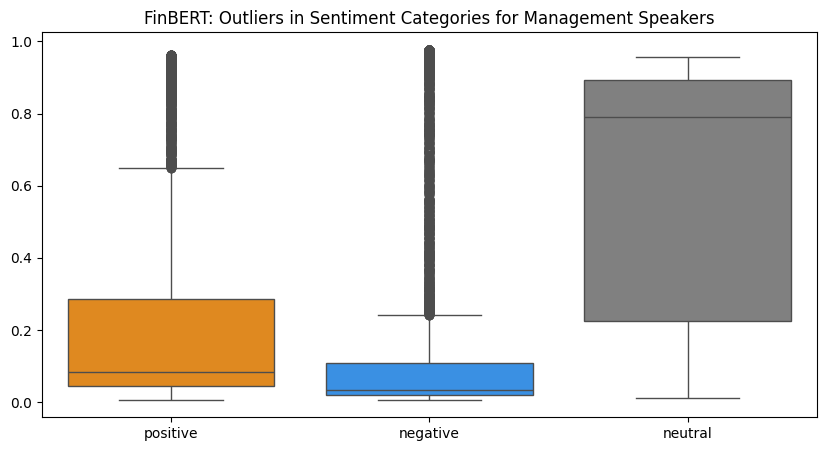

In [141]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -3:], palette=sentiment_palette)
plt.title("FinBERT: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [142]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
sentiment_stats = data.groupby(["quarter", "main_sentiment", "speaker_role","section"]).agg(
    median_score=("main_sentiment_score", "median"),
    std_score=("main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
sentiment_stats = sentiment_stats[sentiment_stats['speaker_role'] != 'analyst']
sentiment_stats.head(10)   

,quarter,main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,negative,management,prepared,0.974530,0.079704
2,2022-Q1,negative,management,qa,0.770536,0.166867
4,2022-Q1,neutral,management,prepared,0.916963,0.045285
5,2022-Q1,neutral,management,qa,0.876016,0.116564
6,2022-Q1,neutral,operator,prepared,0.934292,0.025334
7,2022-Q1,neutral,operator,qa,0.926068,0.107860
9,2022-Q1,positive,management,prepared,0.957169,0.110291
10,2022-Q1,positive,management,qa,0.813592,0.125347
12,2022-Q2,negative,management,prepared,0.973250,0.126333
13,2022-Q2,negative,management,qa,0.793143,0.163648


In [143]:
# Calculate max and mean values for std_score for sentiments
sentiment_std_max = sentiment_stats.groupby('main_sentiment')['std_score'].max()
sentiment_std_mean = sentiment_stats.groupby('main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(sentiment_std_max)
print("\nMean std_score per sentiment:")
print(sentiment_std_mean)

Max std_score per sentiment:
main_sentiment
negative    0.197734
neutral     0.152539
positive    0.169647
Name: std_score, dtype: float64

Mean std_score per sentiment:
main_sentiment
negative    0.148056
neutral     0.072114
positive    0.092163
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [144]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_sentiment_stats = sentiment_stats.pivot_table(index=['quarter', 'main_sentiment'], columns='section', values='median_score').reset_index()
diff_sentiment_stats = diff_sentiment_stats.fillna(0)
diff_sentiment_stats['diff'] = diff_sentiment_stats['qa'] - diff_sentiment_stats['prepared']

In [145]:
diff_sentiment_stats.head(10)

section,quarter,main_sentiment,prepared,qa,diff
0,2022-Q1,negative,0.974530,0.770536,-0.203995
1,2022-Q1,neutral,0.925627,0.901042,-0.024586
2,2022-Q1,positive,0.957169,0.813592,-0.143577
3,2022-Q2,negative,0.973250,0.793143,-0.180107
4,2022-Q2,neutral,0.927114,0.901315,-0.025799
5,2022-Q2,positive,0.954191,0.701649,-0.252542
6,2022-Q3,negative,0.971886,0.746942,-0.224944
7,2022-Q3,neutral,0.912660,0.898770,-0.013889
8,2022-Q3,positive,0.954436,0.619347,-0.335089
9,2022-Q4,negative,0.974792,0.829398,-0.145394


In [146]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_sentiment_std_max = sentiment_std_max.max()
print("Value for error bars: ", all_sentiment_std_max)

Value for error bars:  0.1977337739968308


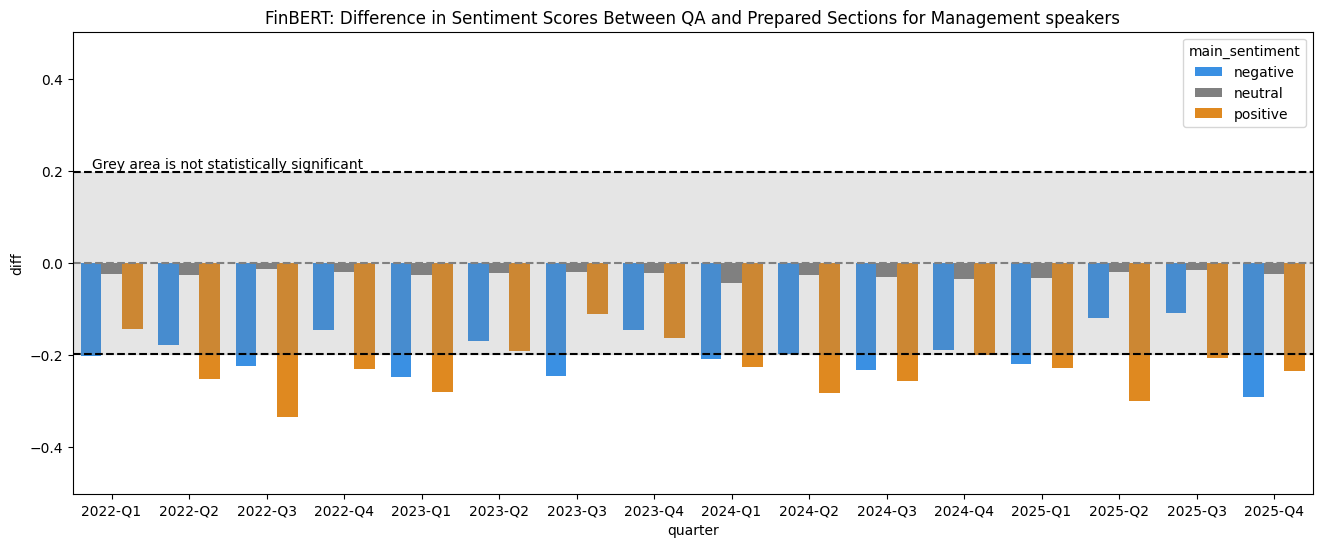

In [147]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/FinBERT_sentiment_differences_{bank_name}.png")

### Merger period Q2 2022 to Q2 2024

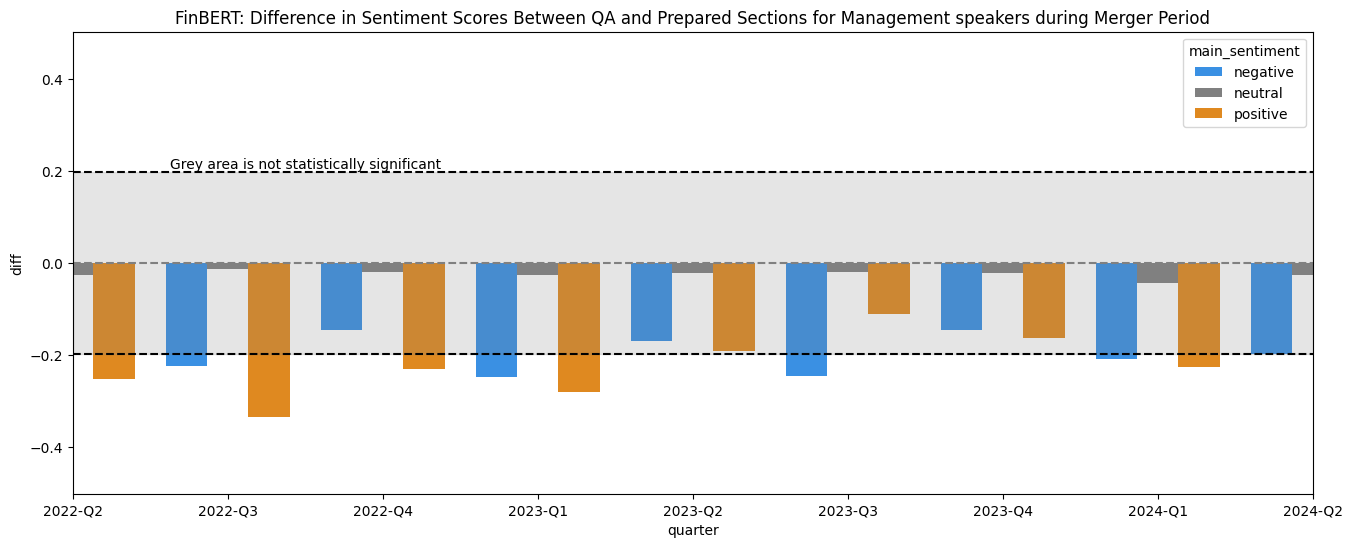

In [148]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

# set x-lim to include from 2022-Q2 to 2024-Q2
plt.xlim("2022-Q2", "2024-Q2")
plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers during Merger Period")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=2.5, 
    y=all_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/FinBERT_sentiment_differences_merge_period_{bank_name}.png")

# Compare FinBERT and BERTemotion

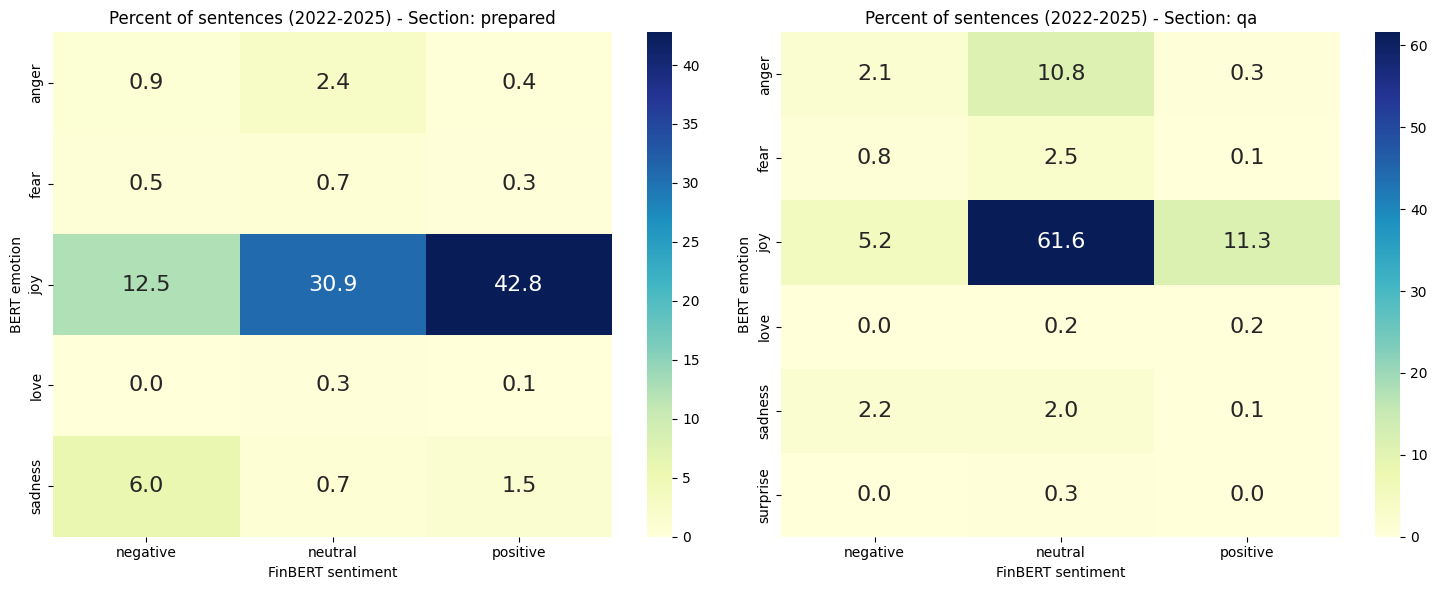

In [149]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# Save data in dataframe for final comparison with other heatmaps
comparison_data = []
for section in sections[:2]:
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    comparison_data.append((section, heatmap_data))
comparison_df1 = pd.concat([df for section, df in comparison_data], keys=[section for section, df in comparison_data])   

# Save figure in bank folder
fig.savefig(f'{results_folder}/BERT_emotion_vs_FinBERT_{bank_name}.png')
plt.show()

# FinBERT-Tone Model

## Build pipeline

In [150]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "yiyanghkust/finbert-tone"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["sentence"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 54918.58it/s]


## Run the model

In [151]:
# Run the model and keep all sentiment scores
basic_FBT_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_FBT_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["FBT_Main_Sentiment"] = [
    max(row, key=row.get, default="Neutral") if row else "Neutral"
    for row in sentiment_rows
]
data["FBT_Main_Sentiment_Score"] = [
    row.get(max(row, key=row.get, default="Neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
# NOTE: FinBERT-Tone requires capital letters for the sentiment labels
for sentiment in ["Positive", "Negative", "Neutral"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [152]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,main_sentiment,main_sentiment_score,positive,negative,neutral,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,Positive,Negative,Neutral
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,neutral,0.879463,0.107888,0.012649,0.879463,Neutral,0.999583,3.815883e-04,3.527616e-05,9.995832e-01
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,neutral,0.940165,0.023411,0.036424,0.940165,Neutral,0.999459,2.959017e-04,2.452073e-04,9.994588e-01
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,neutral,0.913674,0.028846,0.057481,0.913674,Neutral,0.994850,4.590446e-06,5.145093e-03,9.948502e-01
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,neutral,0.945190,0.040750,0.014060,0.945190,Neutral,0.999989,2.464581e-07,1.095779e-05,9.999888e-01
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,neutral,0.943921,0.040531,0.015547,0.943921,Neutral,0.999642,7.133442e-06,3.504210e-04,9.996424e-01
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,neutral,0.928419,0.049427,0.022154,0.928419,Neutral,0.998810,2.999241e-04,8.902154e-04,9.988098e-01
10,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,neutral,0.952012,0.022636,0.025351,0.952012,Neutral,0.999913,1.103179e-05,7.636144e-05,9.999125e-01
11,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38079,...,neutral,0.898367,0.085675,0.015957,0.898367,Neutral,0.999823,1.756469e-04,9.515002e-07,9.998234e-01
12,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38080,...,negative,0.807250,0.020629,0.807250,0.172121,Neutral,0.993212,6.696421e-04,6.118646e-03,9.932116e-01
13,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38081,...,positive,0.957459,0.957459,0.018213,0.024328,Positive,1.000000,1.000000e+00,2.004082e-09,7.721933e-09


In [153]:
# Update FinBERT-Tone column names to make it clearer
data.rename(
    columns={
        "Positive": "FBT_Positive",
        "Negative": "FBT_Negative",
        "Neutral": "FBT_Neutral",
    },
    inplace=True,
)
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,main_sentiment,main_sentiment_score,positive,negative,neutral,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,neutral,0.879463,0.107888,0.012649,0.879463,Neutral,0.999583,3.815883e-04,3.527616e-05,9.995832e-01
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,neutral,0.940165,0.023411,0.036424,0.940165,Neutral,0.999459,2.959017e-04,2.452073e-04,9.994588e-01
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,neutral,0.913674,0.028846,0.057481,0.913674,Neutral,0.994850,4.590446e-06,5.145093e-03,9.948502e-01
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,neutral,0.945190,0.040750,0.014060,0.945190,Neutral,0.999989,2.464581e-07,1.095779e-05,9.999888e-01
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,neutral,0.943921,0.040531,0.015547,0.943921,Neutral,0.999642,7.133442e-06,3.504210e-04,9.996424e-01
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,neutral,0.928419,0.049427,0.022154,0.928419,Neutral,0.998810,2.999241e-04,8.902154e-04,9.988098e-01
10,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,neutral,0.952012,0.022636,0.025351,0.952012,Neutral,0.999913,1.103179e-05,7.636144e-05,9.999125e-01
11,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38079,...,neutral,0.898367,0.085675,0.015957,0.898367,Neutral,0.999823,1.756469e-04,9.515002e-07,9.998234e-01
12,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38080,...,negative,0.807250,0.020629,0.807250,0.172121,Neutral,0.993212,6.696421e-04,6.118646e-03,9.932116e-01
13,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38081,...,positive,0.957459,0.957459,0.018213,0.024328,Positive,1.000000,1.000000e+00,2.004082e-09,7.721933e-09


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

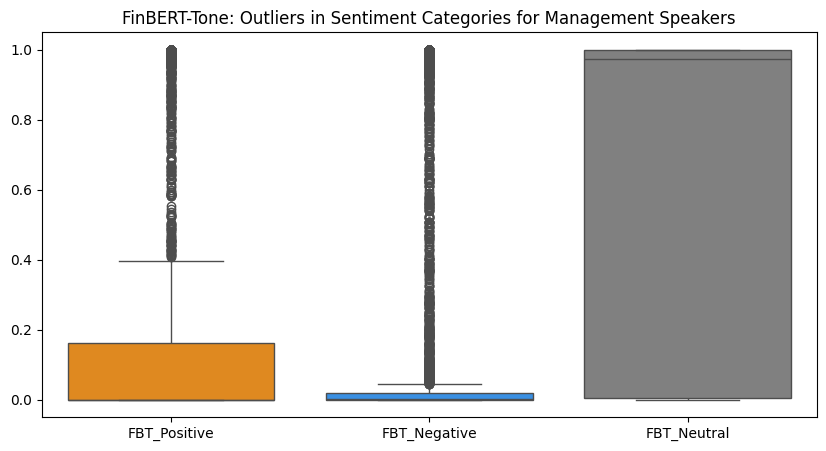

In [154]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
# Use FBT_ columns for the boxplot
sns.boxplot(data=management_data[['FBT_Positive', 'FBT_Negative', 'FBT_Neutral']], palette=sentiment_palette)
plt.title("FinBERT-Tone: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [155]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
FBT_sentiment_stats = data.groupby(["quarter", "FBT_Main_Sentiment", "speaker_role","section"]).agg(
    median_score=("FBT_Main_Sentiment_Score", "median"),
    std_score=("FBT_Main_Sentiment_Score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
FBT_sentiment_stats = FBT_sentiment_stats[FBT_sentiment_stats['speaker_role'] != 'analyst']
FBT_sentiment_stats.head(10)   

,quarter,FBT_Main_Sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,Negative,management,prepared,0.999955,0.034812
2,2022-Q1,Negative,management,qa,0.991103,0.147669
4,2022-Q1,Neutral,management,prepared,0.999832,0.075823
5,2022-Q1,Neutral,management,qa,0.998779,0.099314
6,2022-Q1,Neutral,operator,prepared,0.999521,0.001936
7,2022-Q1,Neutral,operator,qa,0.994187,0.009659
9,2022-Q1,Positive,management,prepared,0.999998,0.059574
10,2022-Q1,Positive,management,qa,0.999999,0.120586
11,2022-Q1,Positive,operator,qa,0.543992,0.016066
13,2022-Q2,Negative,management,prepared,0.999989,0.104942


In [156]:
# Calculate max and mean values for std_score for sentiments
FBT_sentiment_std_max = FBT_sentiment_stats.groupby('FBT_Main_Sentiment')['std_score'].max()
FBT_sentiment_std_mean = FBT_sentiment_stats.groupby('FBT_Main_Sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(FBT_sentiment_std_max)
print("\nMean std_score per sentiment:")
print(FBT_sentiment_std_mean)

Max std_score per sentiment:
FBT_Main_Sentiment
Negative    0.193457
Neutral     0.134639
Positive    0.142400
Name: std_score, dtype: float64

Mean std_score per sentiment:
FBT_Main_Sentiment
Negative    0.095478
Neutral     0.054132
Positive    0.078405
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [157]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_FBT_sentiment_stats = FBT_sentiment_stats.pivot_table(index=['quarter', 'FBT_Main_Sentiment'], columns='section', values='median_score').reset_index()
diff_FBT_sentiment_stats = diff_FBT_sentiment_stats.fillna(0)
diff_FBT_sentiment_stats['diff'] = diff_FBT_sentiment_stats['qa'] - diff_FBT_sentiment_stats['prepared']

In [158]:
diff_FBT_sentiment_stats.head(10)

section,quarter,FBT_Main_Sentiment,prepared,qa,diff
0,2022-Q1,Negative,0.999955,0.991103,-0.008853
1,2022-Q1,Neutral,0.999676,0.996483,-0.003193
2,2022-Q1,Positive,0.999998,0.771996,-0.228003
3,2022-Q2,Negative,0.999989,0.975841,-0.024148
4,2022-Q2,Neutral,0.999619,0.995256,-0.004363
5,2022-Q2,Positive,0.999998,0.834722,-0.165276
6,2022-Q3,Negative,0.999896,0.995801,-0.004094
7,2022-Q3,Neutral,0.999525,0.997670,-0.001855
8,2022-Q3,Positive,0.999992,0.848693,-0.151299
9,2022-Q4,Negative,0.999985,0.994151,-0.005835


In [159]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_FBT_sentiment_std_max = FBT_sentiment_std_max.max()
print("Value for error bars: ", all_FBT_sentiment_std_max)

Value for error bars:  0.19345687849026572


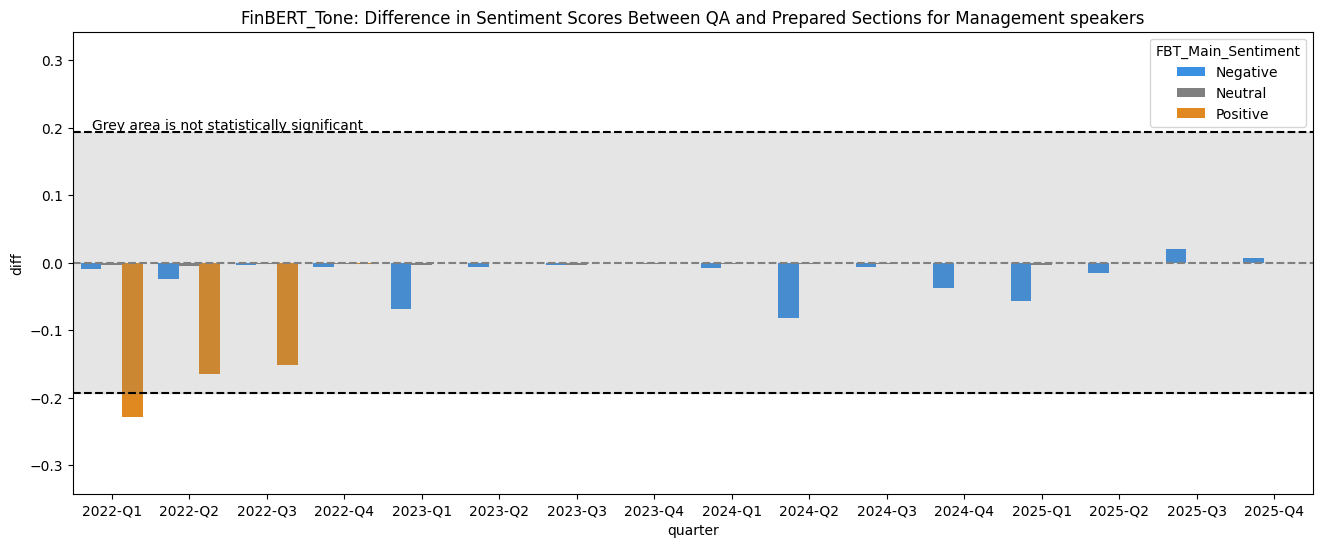

In [160]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_FBT_sentiment_stats, x="quarter", y="diff", hue="FBT_Main_Sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
FBT_diff_range = diff_FBT_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-FBT_diff_range, FBT_diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_FBT_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_FBT_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_FBT_sentiment_std_max,
    all_FBT_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT_Tone: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_FBT_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/FinBERT-Tone_sentiment_differences_{bank_name}.png")

# Compare FinBERT-Tone and BERT-Emotion

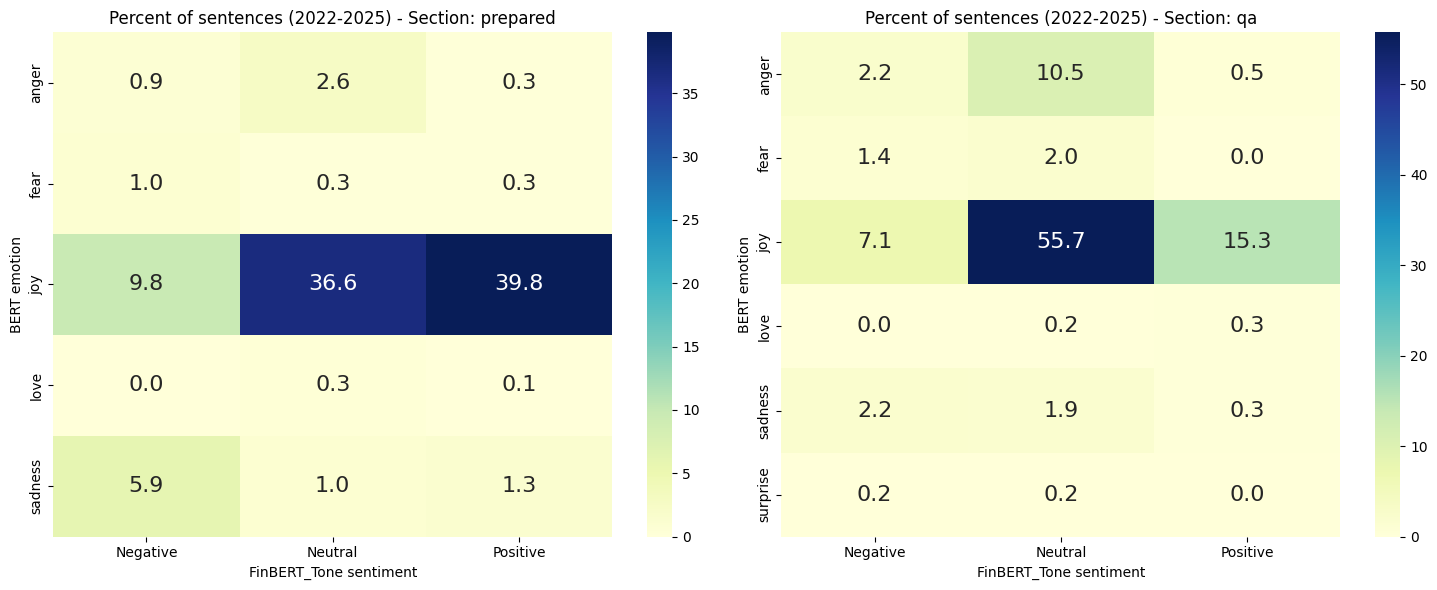

In [161]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT_Tone sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save data in dataframe for final comparison with other heatmaps
comparison_data2 = []
for section in sections[:2]:
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    comparison_data2.append((section, heatmap_data))
comparison_df2 = pd.concat([df for section, df in comparison_data2], keys=[section for section, df in comparison_data2])

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# Save figure in bank folder
fig.savefig(f'{results_folder}/BERT_emotion_vs_FinBERT_Tone_{bank_name}.png')
plt.show()

# Compare FinBERT-Tone and FinBERT

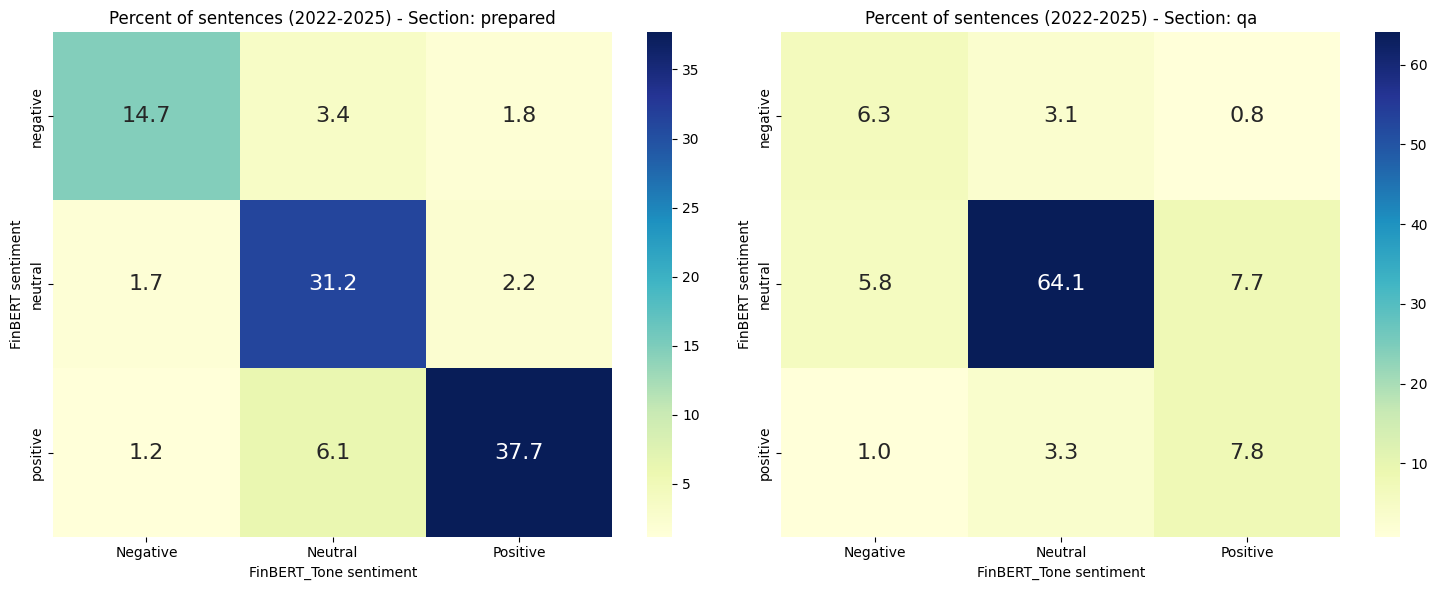

In [162]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'FBT_Main_Sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT_Tone sentiment')
    axes[i].set_ylabel('FinBERT sentiment')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# Save figure in bank folder
fig.savefig(f'{results_folder}/FinBERT_vs_FinBERT_Tone_{bank_name}.png')
plt.show()

# RoBERTa Model

## Build pipeline

In [163]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Load RoBERTa model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["sentence"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 59736.07it/s]


## Run the model

In [164]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["RBT_main_sentiment"] = [
    max(row, key=row.get, default="LABEL_1") if row else "LABEL_1"
    for row in sentiment_rows
]
data["RBT_main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="LABEL_1"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["LABEL_0", "LABEL_1", "LABEL_2"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]
data.rename(columns={"LABEL_0": "RBT_negative", "LABEL_1": "RBT_neutral", "LABEL_2": "RBT_positive"}, inplace=True)

# Map main_sentiment to "LABEL_0": "negative","LABEL_1": "neutral" and "LABEL_2": "positive"
label_mapping = {
    "LABEL_0": "RBT_negative",
    "LABEL_1": "RBT_neutral",
    "LABEL_2": "RBT_positive",
}
data["RBT_main_sentiment"] = data["RBT_main_sentiment"].map(label_mapping)

In [165]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,FBT_Main_Sentiment,FBT_Main_Sentiment_Score,FBT_Positive,FBT_Negative,FBT_Neutral,RBT_main_sentiment,RBT_main_sentiment_score,RBT_negative,RBT_neutral,RBT_positive
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,Neutral,0.999583,3.815883e-04,3.527616e-05,9.995832e-01,RBT_positive,0.856688,0.001518,0.141795,0.856688
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,Neutral,0.999459,2.959017e-04,2.452073e-04,9.994588e-01,RBT_neutral,0.839733,0.094833,0.839733,0.065434
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,Neutral,0.994850,4.590446e-06,5.145093e-03,9.948502e-01,RBT_neutral,0.614816,0.367106,0.614816,0.018077
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,Neutral,0.999989,2.464581e-07,1.095779e-05,9.999888e-01,RBT_neutral,0.777775,0.005349,0.777775,0.216875
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,Neutral,0.999642,7.133442e-06,3.504210e-04,9.996424e-01,RBT_neutral,0.858293,0.016801,0.858293,0.124906
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,Neutral,0.998810,2.999241e-04,8.902154e-04,9.988098e-01,RBT_neutral,0.731557,0.054493,0.731557,0.213950
10,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,Neutral,0.999913,1.103179e-05,7.636144e-05,9.999125e-01,RBT_neutral,0.817101,0.024044,0.817101,0.158855
11,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38079,...,Neutral,0.999823,1.756469e-04,9.515002e-07,9.998234e-01,RBT_neutral,0.741777,0.009968,0.741777,0.248255
12,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38080,...,Neutral,0.993212,6.696421e-04,6.118646e-03,9.932116e-01,RBT_neutral,0.679392,0.262972,0.679392,0.057636
13,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38081,...,Positive,1.000000,1.000000e+00,2.004082e-09,7.721933e-09,RBT_positive,0.927091,0.001039,0.071870,0.927091


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

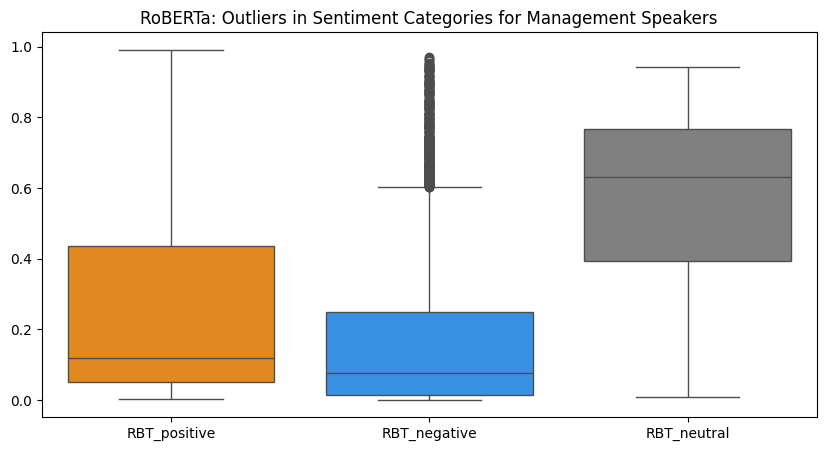

In [166]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
# Use RBT_ columns for the boxplot
sns.boxplot(data=management_data[['RBT_positive', 'RBT_negative', 'RBT_neutral']], palette=sentiment_palette)
plt.title("RoBERTa: Outliers in Sentiment Categories for Management Speakers")
plt.show()

## Calculate quarterly sentiment values (Management not Analyst)

In [167]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
RBT_sentiment_stats = data.groupby(["quarter", "RBT_main_sentiment", "speaker_role","section"]).agg(
    median_score=("RBT_main_sentiment_score", "median"),
    std_score=("RBT_main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
RBT_sentiment_stats = RBT_sentiment_stats[RBT_sentiment_stats['speaker_role'] != 'analyst']
RBT_sentiment_stats.head(10)   

,quarter,RBT_main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,RBT_negative,management,prepared,0.596611,0.065469
2,2022-Q1,RBT_negative,management,qa,0.610444,0.154623
4,2022-Q1,RBT_neutral,management,prepared,0.721991,0.129662
5,2022-Q1,RBT_neutral,management,qa,0.714201,0.115008
6,2022-Q1,RBT_neutral,operator,prepared,0.777775,0.097626
7,2022-Q1,RBT_neutral,operator,qa,0.912985,0.084465
9,2022-Q1,RBT_positive,management,prepared,0.822074,0.147864
10,2022-Q1,RBT_positive,management,qa,0.757614,0.159966
11,2022-Q1,RBT_positive,operator,prepared,0.856688,0.000000
12,2022-Q1,RBT_positive,operator,qa,0.986710,0.000763


In [168]:
# Calculate max and mean values for std_score for sentiments
RBT_sentiment_std_max = RBT_sentiment_stats.groupby('RBT_main_sentiment')['std_score'].max()
RBT_sentiment_std_mean = RBT_sentiment_stats.groupby('RBT_main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(RBT_sentiment_std_max)
print("\nMean std_score per sentiment:")
print(RBT_sentiment_std_mean)

Max std_score per sentiment:
RBT_main_sentiment
RBT_negative    0.154623
RBT_neutral     0.131461
RBT_positive    0.240748
Name: std_score, dtype: float64

Mean std_score per sentiment:
RBT_main_sentiment
RBT_negative    0.104294
RBT_neutral     0.101421
RBT_positive    0.086411
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [169]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_RBT_sentiment_stats = RBT_sentiment_stats.pivot_table(index=['quarter', 'RBT_main_sentiment'], columns='section', values='median_score').reset_index()
diff_RBT_sentiment_stats = diff_RBT_sentiment_stats.fillna(0)
diff_RBT_sentiment_stats['diff'] = diff_RBT_sentiment_stats['qa'] - diff_RBT_sentiment_stats['prepared']

In [170]:
diff_RBT_sentiment_stats.head(10)

section,quarter,RBT_main_sentiment,prepared,qa,diff
0,2022-Q1,RBT_negative,0.596611,0.610444,0.013833
1,2022-Q1,RBT_neutral,0.749883,0.813593,0.063710
2,2022-Q1,RBT_positive,0.839381,0.872162,0.032781
3,2022-Q2,RBT_negative,0.615265,0.705928,0.090664
4,2022-Q2,RBT_neutral,0.750442,0.787057,0.036615
5,2022-Q2,RBT_positive,0.772864,0.892031,0.119167
6,2022-Q3,RBT_negative,0.619223,0.642715,0.023492
7,2022-Q3,RBT_neutral,0.753081,0.808591,0.055510
8,2022-Q3,RBT_positive,0.766548,0.908564,0.142017
9,2022-Q4,RBT_negative,0.604900,0.645405,0.040505


In [171]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_RBT_sentiment_std_max = RBT_sentiment_std_max.max()
print("Value for error bars: ", all_RBT_sentiment_std_max)

Value for error bars:  0.24074831993138163


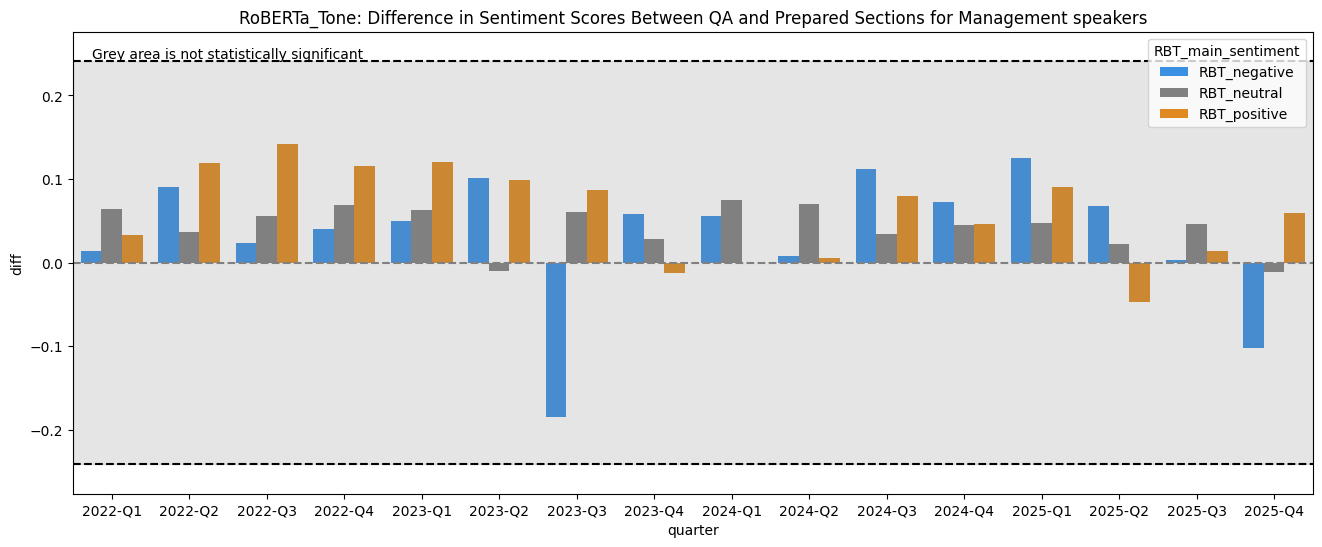

In [172]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_RBT_sentiment_stats, x="quarter", y="diff", hue="RBT_main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_RBT_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_RBT_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_RBT_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_RBT_sentiment_std_max,
    all_RBT_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("RoBERTa_Tone: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=all_RBT_sentiment_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure with bank name in bank folder
plt.savefig(f"{results_folder}/RoBERTa-Tone_sentiment_differences_{bank_name}.png")

# Compare RoBERTa and BERT-Emotion

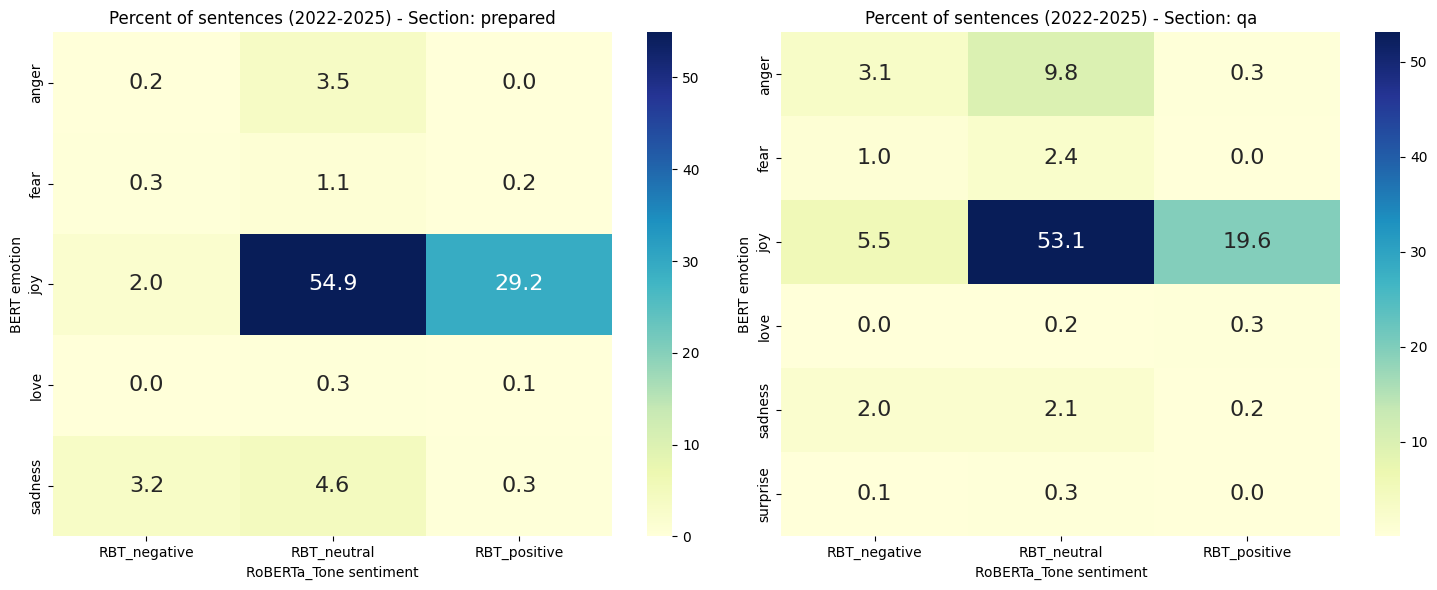

In [173]:
# Create two heatmaps side by side with speaker_role = management but split by section

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'RBT_main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('RoBERTa_Tone sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2022-2025) - Section: {section}')

plt.tight_layout()

# Save data in dataframe for final comparison with other heatmaps
comparison_data3 = []
for section in sections[:2]:
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'RBT_main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    comparison_data3.append((section, heatmap_data))
comparison_df3 = pd.concat([df for section, df in comparison_data3], keys=[section for section, df in comparison_data3])

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

# save figure in bank folder
fig.savefig(f'{results_folder}/BERT_emotion_vs_RoBERTa_Tone_{bank_name}.png')

plt.show()

# Save Output

In [174]:
# Save output as csv file with bank name in title in bank folder
output_file = f"{results_folder}/sentiment_classification_output_{bank_name}.csv"
data.to_csv(output_file, index=False)
print(f"Output saved to {output_file}")

Output saved to results_JPM/sentiment_classification_output_JPM.csv


# Tone Gap Analysis

In [175]:
# Collect results from heatmap comparisons into one dataframe
comparison_df_all = pd.concat([comparison_df1, comparison_df2, comparison_df3], axis=1, keys=['FinBERT', 'FinBERT_Tone', 'RoBERTa_Tone'])
comparison_df_all.head(12)


FinBERT                       FinBERT_Tone  \
                        negative    neutral   positive     Negative   
         main_emotion                                                 
prepared anger          0.858086   2.442244   0.396040     0.858086   
         fear           0.528053   0.726073   0.264026     0.990099   
         joy           12.475248  30.891089  42.772277     9.768977   
         love           0.000000   0.330033   0.132013     0.000000   
         sadness        6.006601   0.726073   1.452145     5.940594   
qa       anger          2.052279  10.844675   0.302441     2.225103   
         fear           0.777706   2.549147   0.108015     1.382588   
         joy            5.249514  61.589976  11.319940     7.128970   
         love           0.000000   0.237632   0.237632     0.000000   
         sadness        2.160294   2.030676   0.129618     2.160294   
         surprise       0.021603   0.345647   0.043206     0.216029   

                                            RoBERTa_Tone              \
                         Neutral   Positive RBT_negative RBT_neutral   
         main_emotion                                                  
prepared anger          2.574257   0.264026     0.198020    3.498350   
         fear           0.264026   0.264026     0.264026    1.056106   
         joy           36.567657  39.801980     1.980198   54.917492   
         love           0.330033   0.132013     0.000000    0.330033   
         sadness        0.990099   1.254125     3.234323    4.620462   
qa       anger         10.520631   0.453662     3.089220    9.786131   
         fear           2.030676   0.021603     0.993735    2.419529   
         joy           55.735580  15.294880     5.465543   53.100022   
         love           0.194426   0.280838     0.021603    0.151221   
         sadness        1.901059   0.259235     2.030676    2.073882   
         surprise       0.151221   0.043206     0.064809    0.324044   

                                    
                      RBT_positive  
         main_emotion               
prepared anger            0.000000  
         fear             0.198020  
         joy             29.240924  
         love             0.132013  
         sadness          0.330033  
qa       anger            0.324044  
         fear             0.021603  
         joy             19.593865  
         love             0.302441  
         sadness          0.216029  
         surprise         0.021603

In [176]:
# Create a dataframe just for main_emotion = 'joy'
comparison_df_joy = comparison_df_all.xs('joy', level=1, axis=0)
comparison_df_joy.head(12)

FinBERT                       FinBERT_Tone                       \
           negative    neutral   positive     Negative    Neutral  Positive   
prepared  12.475248  30.891089  42.772277     9.768977  36.567657  39.80198   
qa         5.249514  61.589976  11.319940     7.128970  55.735580  15.29488   

         RoBERTa_Tone                           
         RBT_negative RBT_neutral RBT_positive  
prepared     1.980198   54.917492    29.240924  
qa           5.465543   53.100022    19.593865

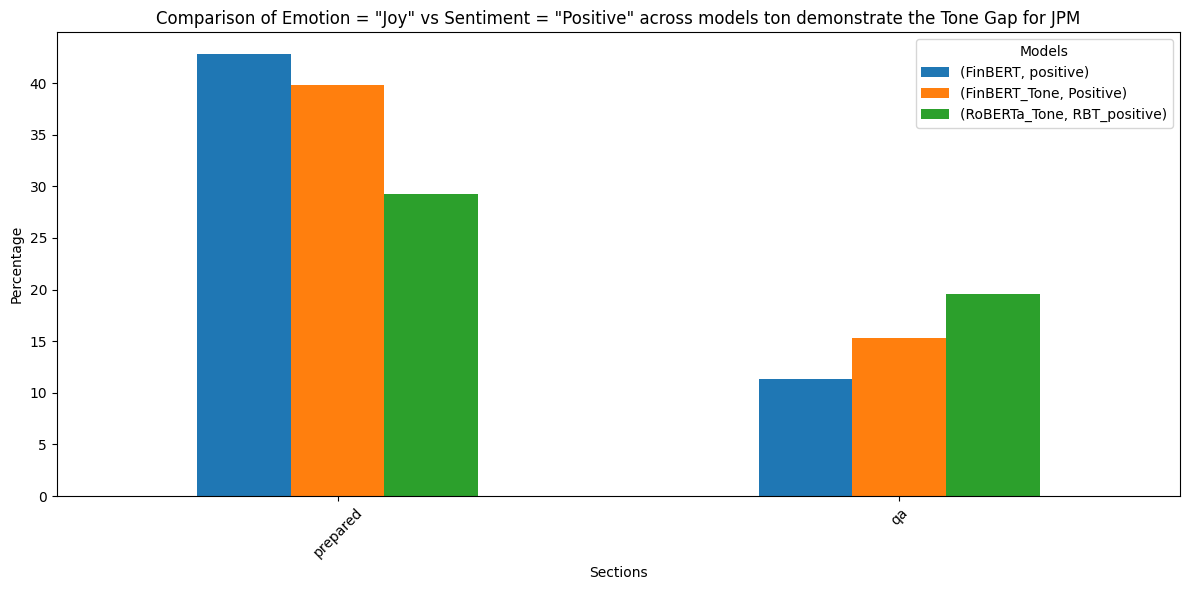

In [177]:
# Plot "joy" vs positive, Positive and RBT_positive for prepared and qa categories
comparison_df_joy_subset = comparison_df_joy.loc[:, [('FinBERT', 'positive'), ('FinBERT_Tone', 'Positive'), ('RoBERTa_Tone', 'RBT_positive')]]
comparison_df_joy_subset = comparison_df_joy_subset.loc[['prepared', 'qa']]
comparison_df_joy_subset.plot(kind='bar', figsize=(12, 6))
plt.title(f'Comparison of Emotion = "Joy" vs Sentiment = "Positive" across models ton demonstrate the Tone Gap for {bank_name}')
plt.ylabel('Percentage')
plt.xlabel('Sections')
plt.xticks(rotation=45)
plt.legend(title='Models')
plt.tight_layout()
# save figure for bank name
plt.savefig(f'{results_folder}/joy_vs_positive_{bank_name}.png')
plt.show()


# Apply BERTopic to sentences classified by FinBERT sentiments

In [178]:
data[['cleaned_text','sentence']].head(20)

,cleaned_text,sentence
1,"[welcome, jpmorgan, chase, first, quarter, ear...",Welcome to JPMorgan Chase's First Quarter 2022...
2,"[call, recorded]",This call is being recorded.
3,"[line, muted, duration, call]",Your line will be muted for the duration of th...
4,"[go, live, presentation]",We will now go live to the presentation.
6,"[time, would, like, turn, call, jpmorgan, chas...","At this time, I would like to turn the call ov..."
7,"[mr, please, ahead]","Mr. Barnum, please be ahead."
10,"[presentation, available, website, please, ref...",The presentation is available on our website a...
11,"[starting, page, firm, reported, net, income, ...","Starting on page 1, the firm reported net inco..."
12,"[result, include, approximately, million, cred...",These results include approximately $900 milli...
13,"[regarding, loan, growth, continuing, see, pos...","Regarding loan growth, we're continuing to see..."


In [179]:
# Check cleaned_text for words like "thats" and "dont"
targets = {"thats", "dont"}
data[data["cleaned_text"].apply(
    lambda t: isinstance(t, (list, tuple)) and any(w.lower() in targets for w in t)
)]
# Show these sentences containing the target words
data.loc[data["cleaned_text"].apply(
    lambda t: isinstance(t, (list, tuple)) and any(w.lower() in targets for w in t)
), "cleaned_text"]

Series([], Name: cleaned_text, dtype: object)

## Sentences where FinBERT = Negative

In [180]:
# Create dataframe with sentences and speakers and quarters but only where main_sentiment = negative

negative_sentences = data[data['main_sentiment'] == 'negative'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
negative_sentences = negative_sentences.sort_values(by=['quarter', 'speaker_role'])

negative_sentences.head(4)

,quarter,speaker_name,speaker_role,sentence,cleaned_text,main_sentiment,main_sentiment_score
318,2022-Q1,Glenn Schorr,analyst,Maybe the last quickie on credit is just with ...,"[maybe, last, quickie, credit, everybody, job,...",negative,0.541193
332,2022-Q1,Gerard Cassidy,analyst,How much was it due to inflation?,"[much, due, inflation]",negative,0.526513
333,2022-Q1,Gerard Cassidy,analyst,"And when you made that comment, is it because ...","[made, comment, concerned, lower, end, consume...",negative,0.591521
358,2022-Q1,Mike Mayo,analyst,"But the since quarter end, AOCI probably has g...","[since, quarter, end, aoci, probably, gotten, ...",negative,0.923125


### BERTopic Analysis using function to apply to any year

In [181]:
import ast
from bertopic import BERTopic
from umap import UMAP

# Not sure what ast and UMAP actually do !
# ast is used to safely evaluate strings containing Python literals (like lists) into actual Python objects.
# UMAP is a dimensionality reduction technique often used to preprocess data for clustering or topic modeling.

def plot_negative_topics_for_year(data, year, bank=bank_name, min_topic_size=10, top_n_words=3):
    """Run BERTopic on a year's negative sentences and plot topic counts as a bar chart.

    Returns (topic_model, topic_info), or (None, None) if no topics were found.
    """
    year = str(year)
    quarters = [f"{year}-Q{q}" for q in range(1, 5)]

    # Negative sentences for the year
    yr_data = data[(data["main_sentiment"] == "negative") & (data["quarter"].isin(quarters))]

    # Adapt text from "strings of lists" format in csv file, dropping empty sentences
    #texts = [" ".join(ast.literal_eval(t)) for t in yr_data["cleaned_text"]]
    texts = [" ".join(tokens) for tokens in yr_data["cleaned_text"]]
    texts = [t for t in texts if t.strip() != ""]
    print(f"Number of negative sentences for BERTopic modelling in {year}: {len(texts)}")

    topic_model = BERTopic(
        umap_model=UMAP(random_state=42, n_jobs=1),
        min_topic_size=min_topic_size,
        calculate_probabilities=False,
    )
    topic_model.fit_transform(texts)
    topic_info = topic_model.get_topic_info()

    plot_info = topic_info[topic_info["Topic"] != -1].sort_values("Count")  # drop the outlier "topic"
    if plot_info.empty:
        print(f"No topics found for {year} (only outliers); try a smaller min_topic_size.")
        return None, topic_info

    # Shorten names like "0_rates_margin_nii_cost" to "rates, margin, nii"
    labels = [", ".join(name.split("_")[1:1 + top_n_words]) for name in plot_info["Name"]]

    fig, ax = plt.subplots(figsize=(10, 0.45 * len(plot_info) + 1.5))
    bars = ax.barh(labels, plot_info["Count"], color="steelblue")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of negative sentences")
    ax.set_title(f"{bank} negative sentences by BERTopic topic for year = {year}")
    plt.tight_layout()
    plt.show()
    return topic_model, topic_info

Number of negative sentences for BERTopic modelling in 2022: 269


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6843.45it/s]


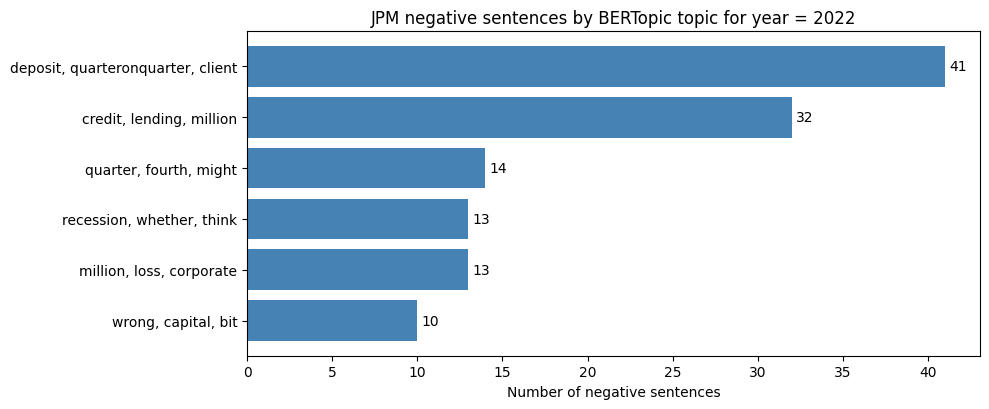

Number of negative sentences for BERTopic modelling in 2023: 238


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13464.23it/s]


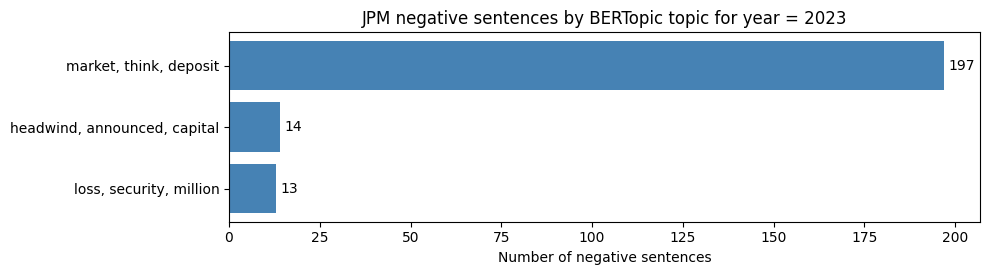

Number of negative sentences for BERTopic modelling in 2024: 206


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13713.40it/s]


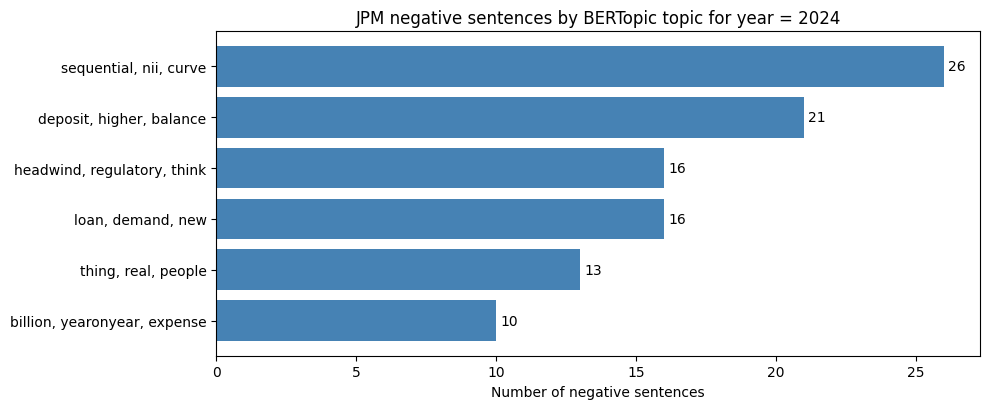

Number of negative sentences for BERTopic modelling in 2025: 206


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17696.76it/s]


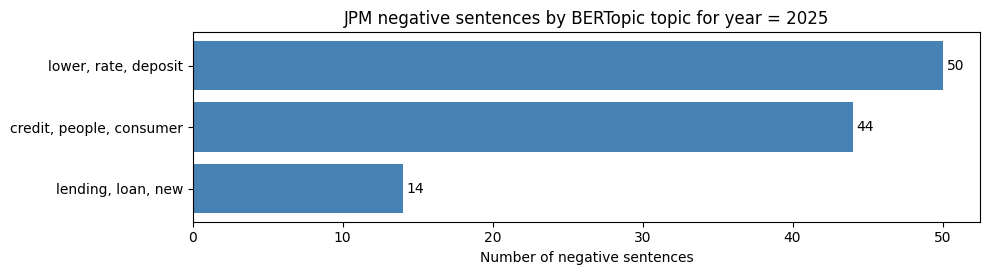

In [182]:
YR_topic_model_22, YR_topic_info_22 = plot_negative_topics_for_year(data, "2022")
YR_topic_model_23, YR_topic_info_23 = plot_negative_topics_for_year(data, "2023")
YR_topic_model_24, YR_topic_info_24 = plot_negative_topics_for_year(data, "2024")
YR_topic_model_25, YR_topic_info_25 = plot_negative_topics_for_year(data, "2025")


In [183]:
# Collect yr_topic_info for all years into one dataframe for plotting, include year as a column
all_YR_topic_info = pd.concat([
    YR_topic_info_22.assign(year="2022"),
    YR_topic_info_23.assign(year="2023"),
    YR_topic_info_24.assign(year="2024"),
    YR_topic_info_25.assign(year="2025")
])
all_YR_topic_info.reset_index(drop=True, inplace=True)

In [184]:
# Add new column for plotting as legend to all_YR_topic_info
# remove numbers and replace underscores with commas
all_YR_topic_info["Legend"] = all_YR_topic_info["Name"].apply(
    lambda x: ", ".join(x.split("_")[1:])
)
all_YR_topic_info.head()


,Topic,Count,Name,Representation,Representative_Docs,year,Legend
0,-1,146,-1_market_year_revenue_quarter,"[market, year, revenue, quarter, lower, yearon...",[market revenue million record first quarter l...,2022,"market, year, revenue, quarter"
1,0,41,0_deposit_quarteronquarter_client_rate,"[deposit, quarteronquarter, client, rate, thin...",[client investment asset yearonyear driven mar...,2022,"deposit, quarteronquarter, client, rate"
2,1,32,1_credit_lending_million_billion,"[credit, lending, million, billion, lower, loa...",[nir ex market billion predominantly driven lo...,2022,"credit, lending, million, billion"
3,2,14,2_quarter_fourth_might_low,"[quarter, fourth, might, low, little, closer, ...",[since quarter end aoci probably gotten worse ...,2022,"quarter, fourth, might, low"
4,3,13,3_million_loss_corporate_net,"[million, loss, corporate, net, due, nii, bill...","[corporate reported net loss million, corporat...",2022,"million, loss, corporate, net"


### BERTopic - final plot

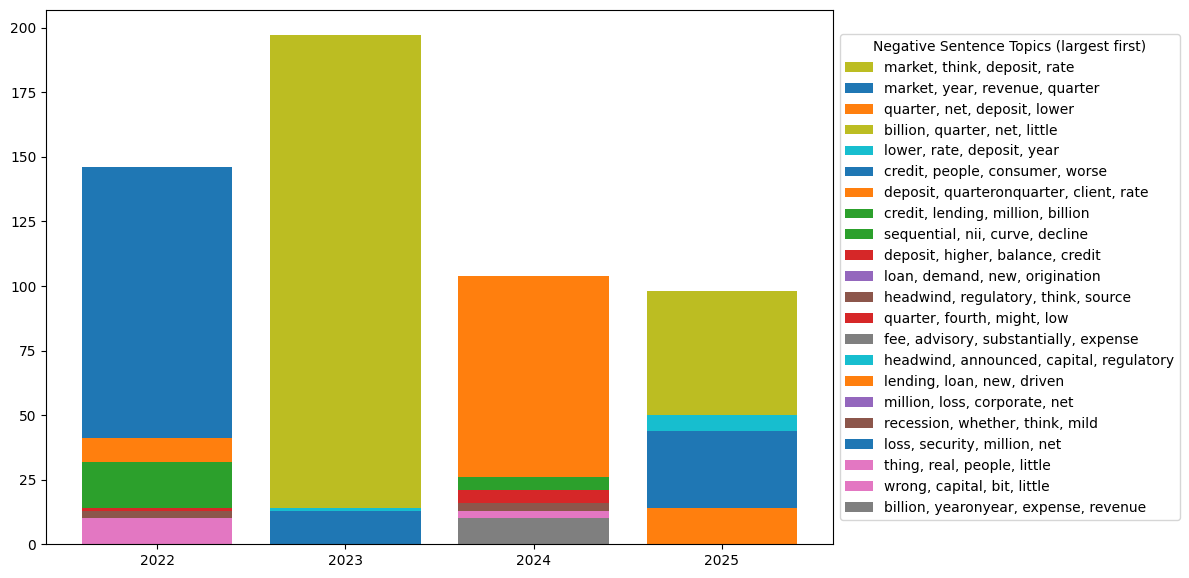

In [185]:

fig, ax = plt.subplots(figsize=(12, 6))

for topic in all_YR_topic_info["Name"].unique():
    topic_data = all_YR_topic_info[all_YR_topic_info["Name"] == topic]
    ax.bar(topic_data["year"], topic_data["Count"], label=topic_data["Legend"].iloc[0])

# Total count per legend label, used for ordering
totals = all_YR_topic_info.groupby("Legend")["Count"].sum()

handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: totals[labels[i]], reverse=True)

ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="center left",
    bbox_to_anchor=(1, 0.5),   # legend at the side
    title="Negative Sentence Topics (largest first)",
)
plt.tight_layout()
# save figure in bank folder
plt.savefig(f"{results_folder}/negative_sentence_topics_by_year_for_{bank_name}.png")
plt.show()

### BertTopic by Quarter

In [186]:
import ast
from bertopic import BERTopic
from umap import UMAP
import pandas as pd

def _cleaned_to_text(value):
    """Turn a token list, a stringified token list, or a plain string into one string."""
    if isinstance(value, (list, tuple)):
        return " ".join(map(str, value)).strip()
    if isinstance(value, str):
        v = value.strip()
        if v.startswith("[") and v.endswith("]"):
            try:
                return " ".join(map(str, ast.literal_eval(v))).strip()
            except (ValueError, SyntaxError):
                pass
        return v
    return ""

def find_top_negative_topics_per_quarter(
    data,
    bank=None,
    min_topic_size=5,
    top_n_topics=3,
    top_n_words=5,
    n_examples=2,
    text_col="cleaned_text",
):
    required = {"quarter", "main_sentiment", text_col}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    if bank is not None and "bank" not in data.columns:
        raise ValueError("A 'bank' column is required when filtering by bank.")
    if min_topic_size < 2 or top_n_topics < 1:
        raise ValueError("min_topic_size must be at least 2 and top_n_topics at least 1.")

    subset = data[data["main_sentiment"].eq("negative")].copy()
    if bank is not None:
        subset = subset[subset["bank"].eq(bank)]

    # Original sentences are used for examples when available
    example_col = "sentence" if "sentence" in subset.columns else text_col

    results = []

    for quarter, quarter_data in subset.groupby("quarter", sort=True):
        quarter_data = quarter_data.copy()
        quarter_data["_text"] = quarter_data[text_col].apply(_cleaned_to_text)
        quarter_data = quarter_data[quarter_data["_text"].ne("")]

        if len(quarter_data) < 2:
            print(f"Skipping {quarter}: fewer than 2 non-empty texts.")
            continue

        topic_model = BERTopic(
            umap_model=UMAP(random_state=42, n_jobs=1),
            min_topic_size=min_topic_size,
            calculate_probabilities=False,
        )

        topics, _ = topic_model.fit_transform(quarter_data["_text"].tolist())
        quarter_data["topic"] = topics

        top_topics = (
            topic_model.get_topic_info()
            .query("Topic != -1")
            .sort_values("Count", ascending=False)
            .head(top_n_topics)
        )

        if top_topics.empty:
            print(f"No non-outlier topics found for {quarter}.")
            continue

        for topic in top_topics.itertuples(index=False):
            topic_words = topic_model.get_topic(topic.Topic) or []
            keywords = ", ".join(word for word, _ in topic_words[:top_n_words])
            examples = quarter_data.loc[
                quarter_data["topic"].eq(topic.Topic), example_col
            ].head(n_examples).astype(str).tolist()

            results.append({
                "quarter": quarter,
                "topic": topic.Topic,
                "count": topic.Count,
                "keywords": keywords,
                "example_sentences": examples,
            })

    return pd.DataFrame(results)

In [187]:
top_topics = find_top_negative_topics_per_quarter(data, bank=bank_name)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21462.23it/s]


No non-outlier topics found for 2024-Q4.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13307.05it/s]


No non-outlier topics found for 2025-Q4.


In [188]:
display(top_topics)

,quarter,topic,count,keywords,example_sentences
0,2022-Q1,0,17,"revenue, billion, yearonyear, lower, year",[These results include approximately $900 mill...
1,2022-Q1,1,9,"think, endless, mistake, like, time","[I think it's a complete waste of time., That'..."
2,2022-Q1,2,8,"would, inflation, cash, seeing, delinquency","[So all else equal, you'll see a headwind in t..."
3,2022-Q2,0,8,"whether, still, outlook, think, market",[But given some of the potential bad stuff goi...
4,2022-Q2,1,6,"million, billion, revenue, approximately, equity",[CET1 capital was slightly down as earnings we...
5,2022-Q3,0,45,"market, million, yearonyear, loss, billion",[The only significant item this quarter was di...
6,2022-Q3,1,5,"quarter, fourth, much, low, strain",[Today's guidance for the fourth quarter of th...
7,2022-Q4,0,44,"market, year, lower, yearonyear, billion","[NIR ex Markets was down $3.5 billion or 26%, ..."
8,2022-Q4,1,7,"mistake, huge, prior, another, oversimplifying",[But if you look at prior – and forget what ha...
9,2023-Q1,0,39,"lower, rate, bank, risk, think",[These results included $868 million of net in...


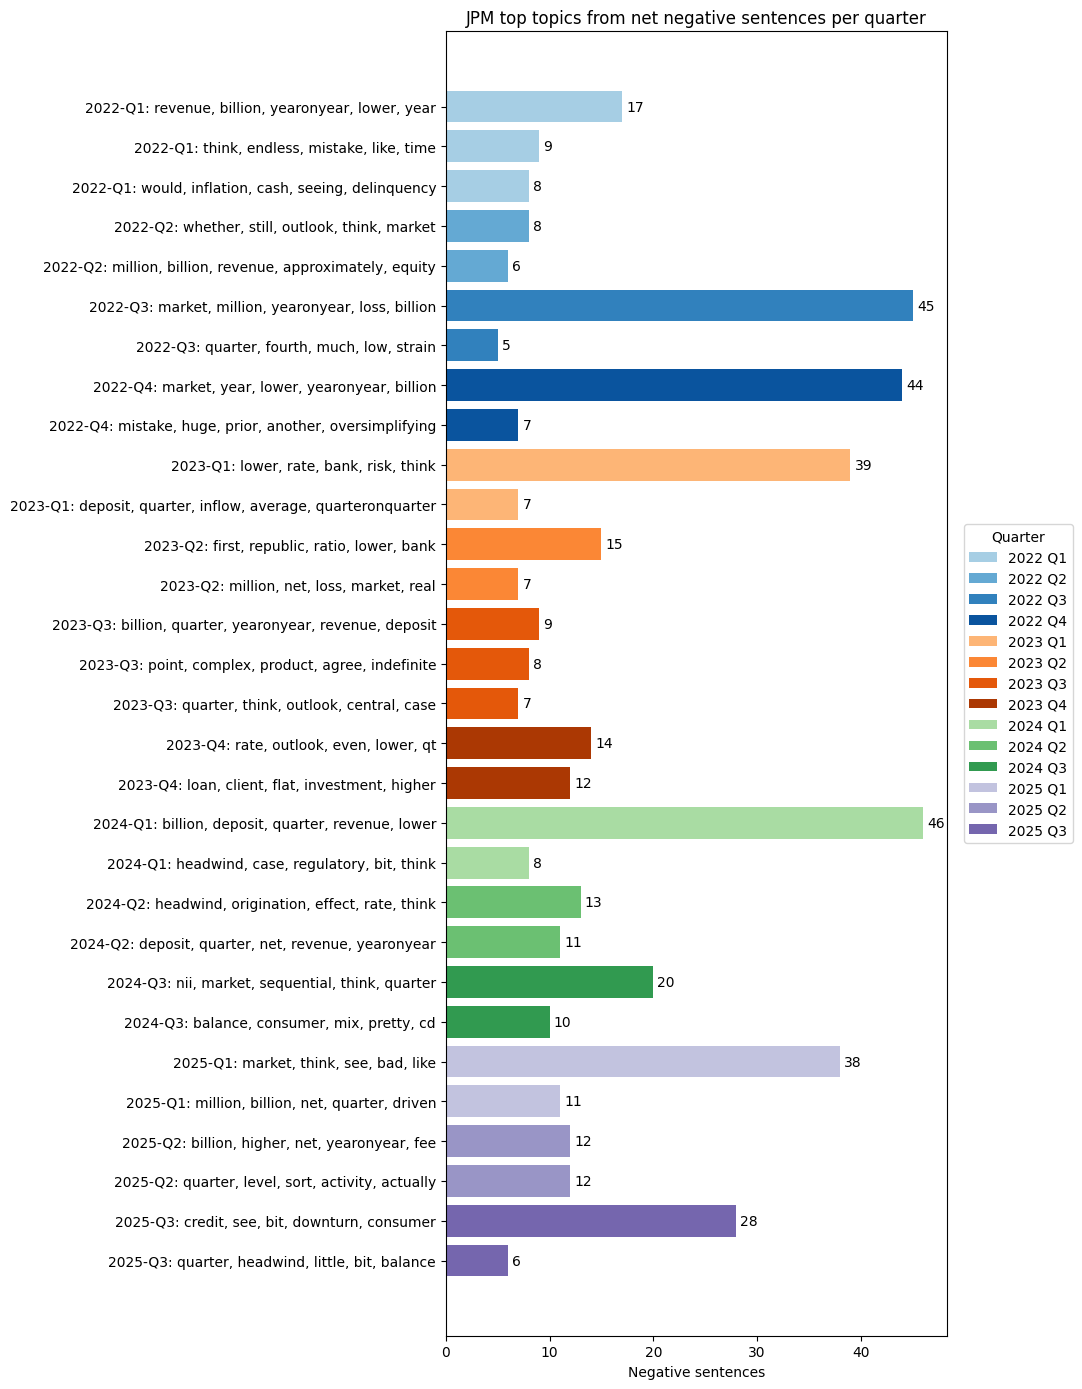

In [189]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_top_topics_single_figure(top_topics, bank=""):
    df = top_topics.copy()
    df["year"] = df["quarter"].str[:4]
    df["q"] = df["quarter"].str[-1].astype(int)

    # Chronological order, largest topic first within each quarter
    df = df.sort_values(["year", "q", "count"], ascending=[True, True, False]).reset_index(drop=True)

    base_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Reds", "Greys"]
    years = sorted(df["year"].unique())
    year_cmap = {y: plt.get_cmap(base_cmaps[i % len(base_cmaps)]) for i, y in enumerate(years)}
    # Q1 lightest -> Q4 darkest
    shade = {1: 0.35, 2: 0.52, 3: 0.69, 4: 0.86}

    colours = [year_cmap[r.year](shade[r.q]) for r in df.itertuples()]


    labels = [f"{r.quarter}: {r.keywords}" for r in df.itertuples()]

    fig, ax = plt.subplots(figsize=(11, 0.4 * len(df) + 2))
    bars = ax.barh(range(len(df)), df["count"], color=colours)
    ax.bar_label(bars, padding=3)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Negative sentences")

    handles = [
        Patch(facecolor=year_cmap[y](shade[q]), label=f"{y} Q{q}")
        for y in years
        for q in sorted(df.loc[df["year"] == y, "q"].unique())
    ]
    ax.legend(handles=handles, title="Quarter", loc="center left",
              bbox_to_anchor=(1.02, 0.5))
    ax.set_title(f"{bank} top topics from net negative sentences per quarter".strip())

    fig.tight_layout()
    # save figure in bank folder
    plt.savefig(f"{results_folder}/negative_sentence_topics_by_quarter_for_{bank_name}.png")

    plt.show()


plot_top_topics_single_figure(top_topics, bank=bank_name)

Recreate topic plot over the acquisition period

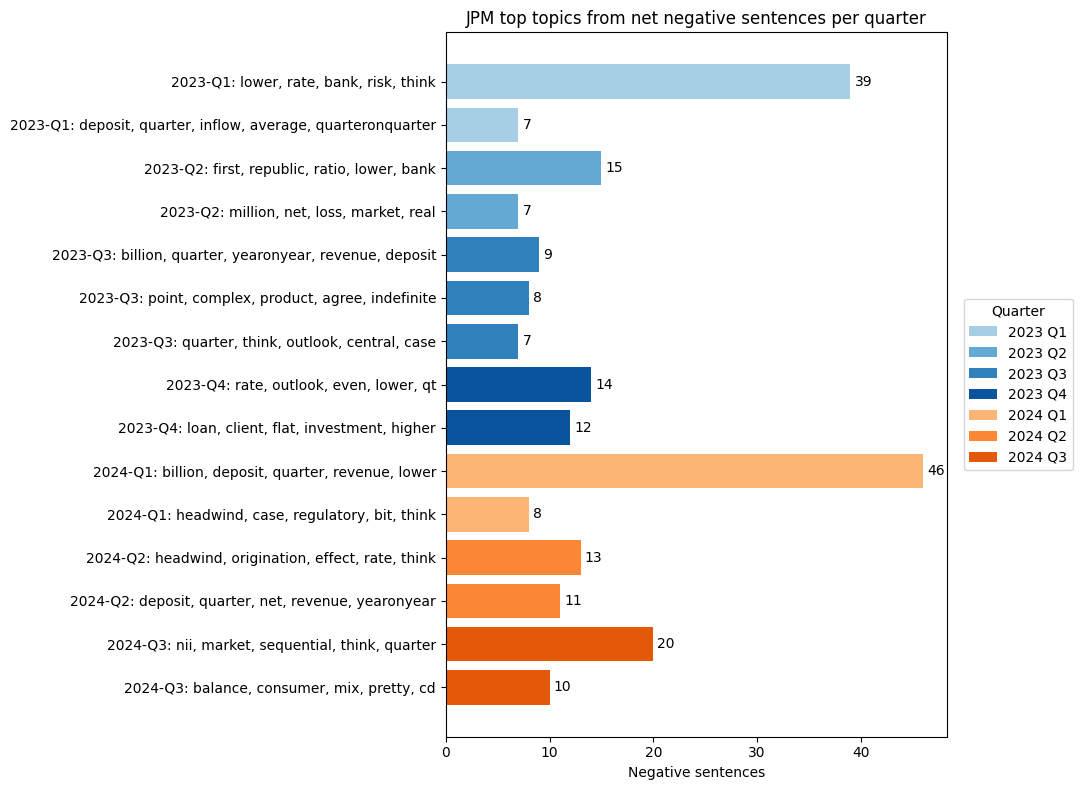

In [190]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_top_topics_single_figure(top_topics, bank=""):
    df = top_topics.copy()
    df["year"] = df["quarter"].str[:4]
    df["q"] = df["quarter"].str[-1].astype(int)

    # Chronological order, largest topic first within each quarter
    # Adjust to plot from 2023-Q1 to 2024-Q4
    df = df[(df["quarter"] >= "2023-Q1") & (df["quarter"] <= "2024-Q4")]
    df = df.sort_values(["year", "q", "count"], ascending=[True, True, False]).reset_index(drop=True)

    base_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Reds", "Greys"]
    years = sorted(df["year"].unique())
    year_cmap = {y: plt.get_cmap(base_cmaps[i % len(base_cmaps)]) for i, y in enumerate(years)}
    # Q1 lightest -> Q4 darkest
    shade = {1: 0.35, 2: 0.52, 3: 0.69, 4: 0.86}

    colours = [year_cmap[r.year](shade[r.q]) for r in df.itertuples()]


    labels = [f"{r.quarter}: {r.keywords}" for r in df.itertuples()]

    fig, ax = plt.subplots(figsize=(11, 0.4 * len(df) + 2))
    bars = ax.barh(range(len(df)), df["count"], color=colours)
    ax.bar_label(bars, padding=3)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Negative sentences")

    handles = [
        Patch(facecolor=year_cmap[y](shade[q]), label=f"{y} Q{q}")
        for y in years
        for q in sorted(df.loc[df["year"] == y, "q"].unique())
    ]
    ax.legend(handles=handles, title="Quarter", loc="center left",
              bbox_to_anchor=(1.02, 0.5))
    ax.set_title(f"{bank} top topics from net negative sentences per quarter".strip())

    fig.tight_layout()
    # save figure in bank folder
    plt.savefig(f"{results_folder}/negative_sentence_topics_by_quarter_for_{bank_name}_merge_period.png")

    plt.show()


plot_top_topics_single_figure(top_topics, bank=bank_name)

In [191]:
# Search sentences for the words "First Republic"
first_republic_sentences = data[data["sentence"].str.contains("First Republic", case=False, na=False)]
print(first_republic_sentences[["quarter", "sentence"]])

      quarter                                           sentence
2944  2023-Q2  These results included the First Republic barg...
2946  2023-Q2  Before giving you more detail on the financial...
2949  2023-Q2  First Republic employees have formally joined ...
2952  2023-Q2  You'll see that in various parts of the presen...
2953  2023-Q2  To make things easier, I'm going to start by d...
...       ...                                                ...
7160  2025-Q1  These results included a First Republic-relate...
7419  2025-Q1  And then just separately, if we look at the de...
7429  2025-Q1     It could be the First Republic accounting, yes
7715  2025-Q1  It is also LCR, it is also G-SIFI, also – and ...
7976  2025-Q2  And the things like Silicon Valley Bank and Fi...

[93 rows x 2 columns]


In [192]:
# Search the cleaned text to ensure it has come across as first and republic
first_republic_cleaned_text = data[data["cleaned_text"].str.contains("First Republic", case=False, na=False)]
print(first_republic_sentences[["quarter", "sentence", "cleaned_text", "main_sentiment"]])

      quarter                                           sentence  \
2944  2023-Q2  These results included the First Republic barg...   
2946  2023-Q2  Before giving you more detail on the financial...   
2949  2023-Q2  First Republic employees have formally joined ...   
2952  2023-Q2  You'll see that in various parts of the presen...   
2953  2023-Q2  To make things easier, I'm going to start by d...   
...       ...                                                ...   
7160  2025-Q1  These results included a First Republic-relate...   
7419  2025-Q1  And then just separately, if we look at the de...   
7429  2025-Q1     It could be the First Republic accounting, yes   
7715  2025-Q1  It is also LCR, it is also G-SIFI, also – and ...   
7976  2025-Q2  And the things like Silicon Valley Bank and Fi...   

                                           cleaned_text main_sentiment  
2944  [result, included, first, republic, bargain, p...       negative  
2946  [giving, detail, financials, le

In [193]:


# Count number of positive, negative and neutral sentences
first_republic_sentiment_counts = first_republic_sentences["main_sentiment"].value_counts()
print("number of positive sentences:", first_republic_sentiment_counts.get("positive", 0))
print("number of negative sentences:", first_republic_sentiment_counts.get("negative", 0))
print("number of neutral sentences:", first_republic_sentiment_counts.get("neutral", 0))

number of positive sentences: 24
number of negative sentences: 11
number of neutral sentences: 58


## Sentences where FinBERT = Positive

In [194]:
# Create dataframe with sentences and speakers and quarters but only where main_sentiment = positive

positive_sentences = data[data['main_sentiment'] == 'positive'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
positive_sentences = data[data['main_sentiment'] == 'positive'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
positive_sentences = positive_sentences.sort_values(by=['quarter', 'speaker_role'])

positive_sentences.shape

(1425, 7)

### BertTopic by Quarter (positive)

In [195]:
import ast
from bertopic import BERTopic
from umap import UMAP
import pandas as pd

def _cleaned_to_text(value):
    """Turn a token list, a stringified token list, or a plain string into one string."""
    if isinstance(value, (list, tuple)):
        return " ".join(map(str, value)).strip()
    if isinstance(value, str):
        v = value.strip()
        if v.startswith("[") and v.endswith("]"):
            try:
                return " ".join(map(str, ast.literal_eval(v))).strip()
            except (ValueError, SyntaxError):
                pass
        return v
    return ""

def find_top_positive_topics_per_quarter(
    data,
    bank=None,
    min_topic_size=5,
    top_n_topics=3,
    top_n_words=5,
    n_examples=2,
    text_col="cleaned_text",
):
    required = {"quarter", "main_sentiment", text_col}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    if bank is not None and "bank" not in data.columns:
        raise ValueError("A 'bank' column is required when filtering by bank.")
    if min_topic_size < 2 or top_n_topics < 1:
        raise ValueError("min_topic_size must be at least 2 and top_n_topics at least 1.")

    subset = data[data["main_sentiment"].eq("positive")].copy()
    if bank is not None:
        subset = subset[subset["bank"].eq(bank)]

    # Original sentences are used for examples when available
    example_col = "sentence" if "sentence" in subset.columns else text_col

    results = []

    for quarter, quarter_data in subset.groupby("quarter", sort=True):
        quarter_data = quarter_data.copy()
        quarter_data["_text"] = quarter_data[text_col].apply(_cleaned_to_text)
        quarter_data = quarter_data[quarter_data["_text"].ne("")]

        if len(quarter_data) < 2:
            print(f"Skipping {quarter}: fewer than 2 non-empty texts.")
            continue

        topic_model = BERTopic(
            umap_model=UMAP(random_state=42, n_jobs=1),
            min_topic_size=min_topic_size,
            calculate_probabilities=False,
        )

        topics, _ = topic_model.fit_transform(quarter_data["_text"].tolist())
        quarter_data["topic"] = topics

        top_topics = (
            topic_model.get_topic_info()
            .query("Topic != -1")
            .sort_values("Count", ascending=False)
            .head(top_n_topics)
        )

        if top_topics.empty:
            print(f"No non-outlier topics found for {quarter}.")
            continue

        for topic in top_topics.itertuples(index=False):
            topic_words = topic_model.get_topic(topic.Topic) or []
            keywords = ", ".join(word for word, _ in topic_words[:top_n_words])
            examples = quarter_data.loc[
                quarter_data["topic"].eq(topic.Topic), example_col
            ].head(n_examples).astype(str).tolist()

            results.append({
                "quarter": quarter,
                "topic": topic.Topic,
                "count": topic.Count,
                "keywords": keywords,
                "example_sentences": examples,
            })

    return pd.DataFrame(results)

In [196]:
top_topics_positive = find_top_positive_topics_per_quarter(data, bank=bank_name)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15741.63it/s]


In [197]:
display(top_topics_positive)

,quarter,topic,count,keywords,example_sentences
0,2022-Q1,0,27,"quarter, going, capital, rate, good","[As a reminder, we exited the fourth quarter w..."
1,2022-Q1,1,15,"expense, investment, client, billion, driven",[Expenses of $19.2 billion were up approximate...
2,2022-Q1,2,7,"loan, ppp, growth, ex, quarteronquarter","[Regarding loan growth, we're continuing to se..."
3,2022-Q2,0,26,"billion, expense, yearonyear, revenue, investment","[Touching on a few highlights, we had another ..."
4,2022-Q2,1,25,"good, shape, feel, consumer, quite","[As we look forward, we are mindful of the ele..."
5,2022-Q2,2,12,"loan, growth, see, balance, continue",[And there continue to be positive trends in l...
6,2022-Q3,0,35,"billion, yearonyear, driven, revenue, higher","[Touching on a few highlights, we had record t..."
7,2022-Q3,1,9,"think, going, starting, firm, increase",[And we are now number 1 in LA in addition to ...
8,2022-Q3,2,7,"good, quarter, think, strong, messaging","[Given our results this quarter, we are well p..."
9,2022-Q4,0,40,"growth, loan, expect, well, company","[This quarter, we had two significant items in..."


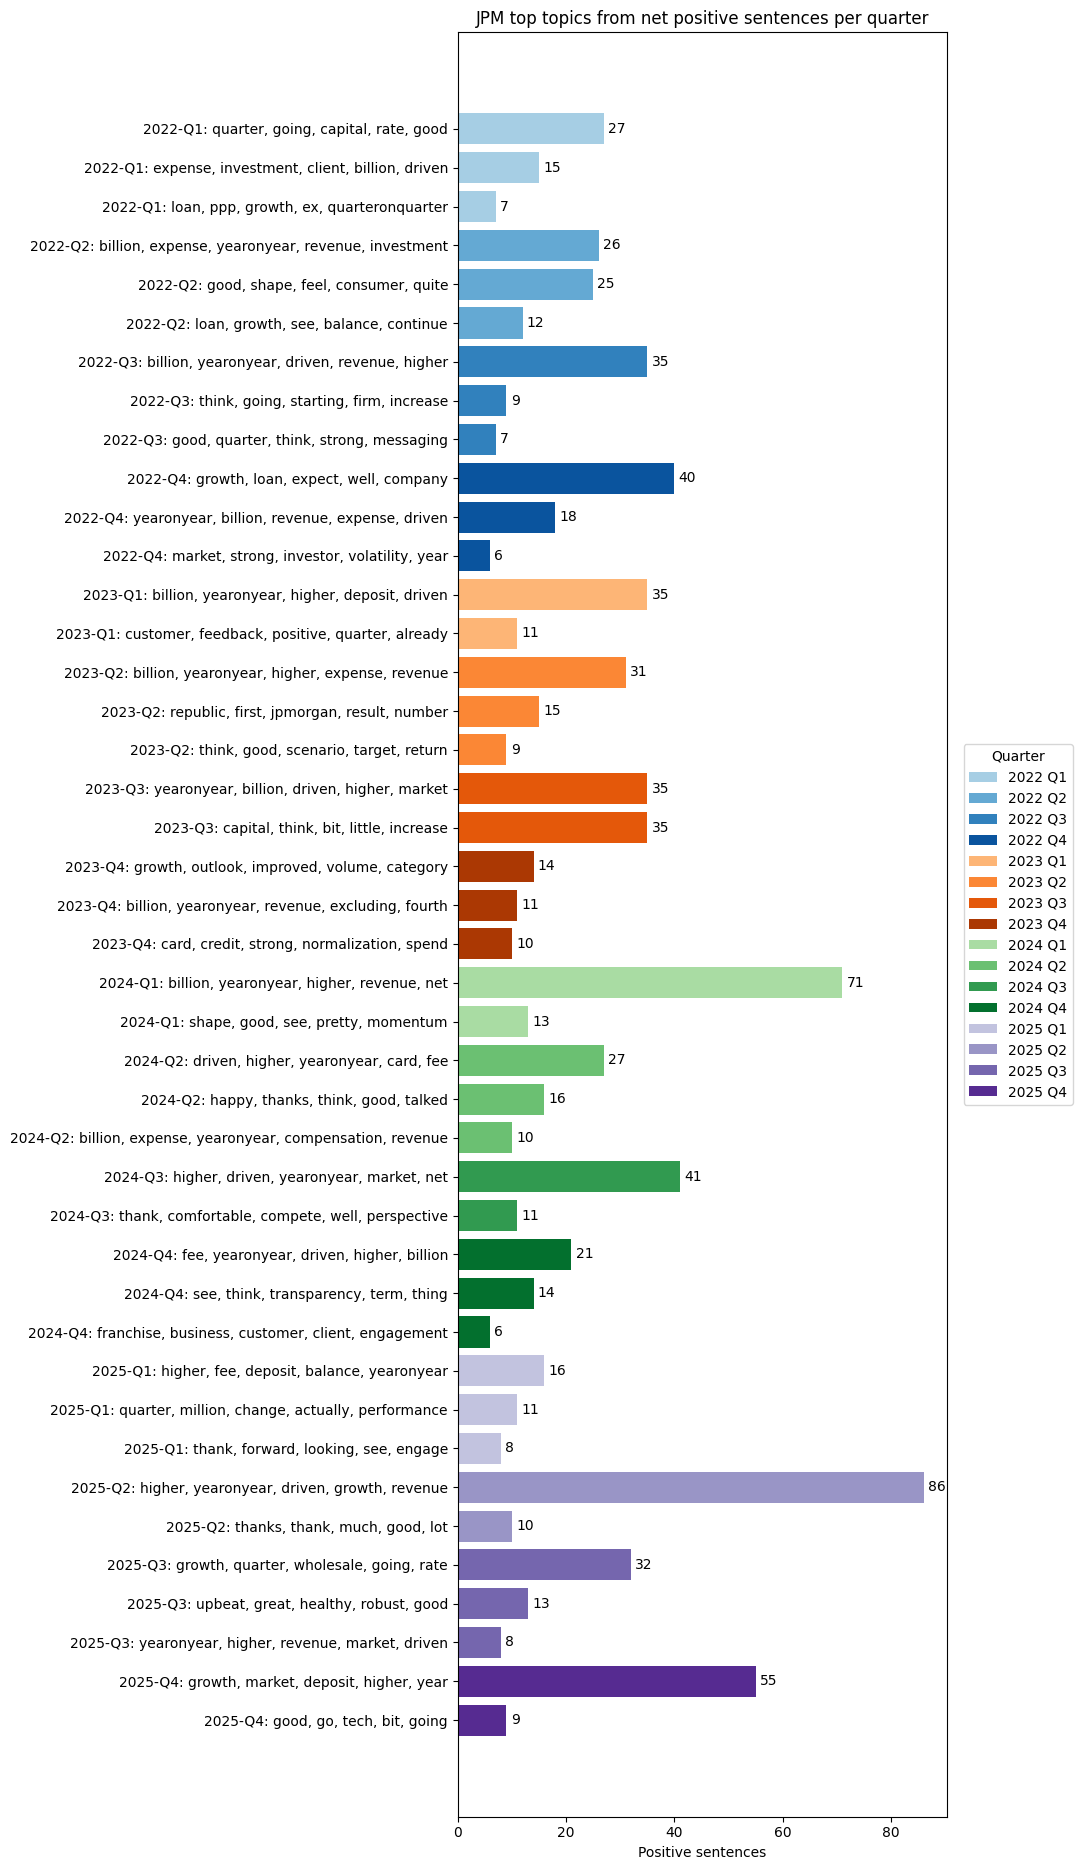

In [198]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_top_topics_single_figure(top_topics, bank=""):
    df = top_topics_positive.copy()
    df["year"] = df["quarter"].str[:4]
    df["q"] = df["quarter"].str[-1].astype(int)

    # Chronological order, largest topic first within each quarter
    df = df.sort_values(["year", "q", "count"], ascending=[True, True, False]).reset_index(drop=True)

    base_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Reds", "Greys"]
    years = sorted(df["year"].unique())
    year_cmap = {y: plt.get_cmap(base_cmaps[i % len(base_cmaps)]) for i, y in enumerate(years)}
    # Q1 lightest -> Q4 darkest
    shade = {1: 0.35, 2: 0.52, 3: 0.69, 4: 0.86}

    colours = [year_cmap[r.year](shade[r.q]) for r in df.itertuples()]


    labels = [f"{r.quarter}: {r.keywords}" for r in df.itertuples()]

    fig, ax = plt.subplots(figsize=(11, 0.4 * len(df) + 2))
    bars = ax.barh(range(len(df)), df["count"], color=colours)
    ax.bar_label(bars, padding=3)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Positive sentences")

    handles = [
        Patch(facecolor=year_cmap[y](shade[q]), label=f"{y} Q{q}")
        for y in years
        for q in sorted(df.loc[df["year"] == y, "q"].unique())
    ]
    ax.legend(handles=handles, title="Quarter", loc="center left",
              bbox_to_anchor=(1.02, 0.5))
    ax.set_title(f"{bank} top topics from net positive sentences per quarter".strip())
    fig.tight_layout()
    # save figure in bank folder
    plt.savefig(f"{results_folder}/positive_sentence_topics_by_quarter_for_{bank_name}.png")

    plt.show()


plot_top_topics_single_figure(top_topics_positive, bank=bank_name)

Recreate the plot over the acquisition period

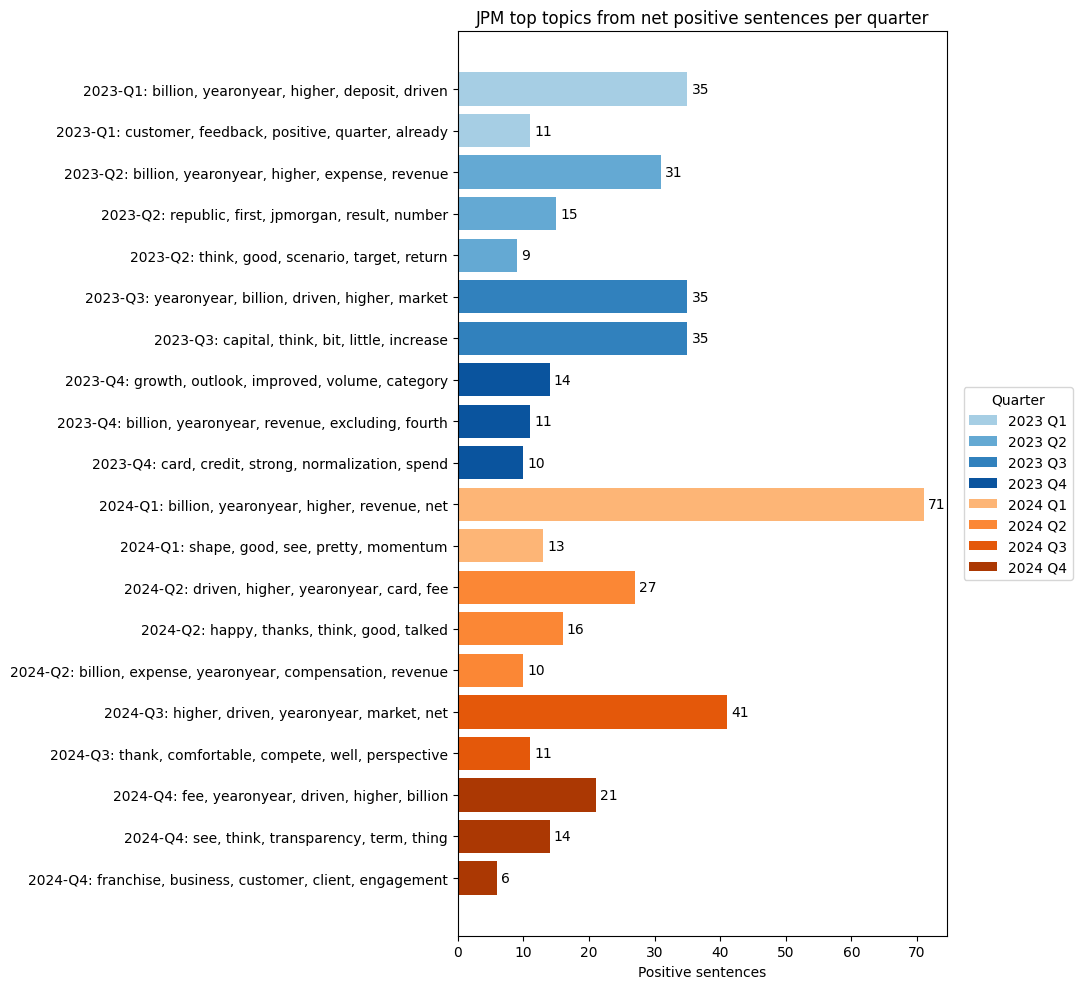

In [199]:


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_top_topics_single_figure(top_topics, bank=""):
    df = top_topics_positive.copy()
    df["year"] = df["quarter"].str[:4]
    df["q"] = df["quarter"].str[-1].astype(int)

    # Chronological order, largest topic first within each quarter
    # Adjust to plot from 2023-Q1 to 2024-Q4
    df = df[(df["quarter"] >= "2023-Q1") & (df["quarter"] <= "2024-Q4")]
    df = df.sort_values(["year", "q", "count"], ascending=[True, True, False]).reset_index(drop=True)

    base_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Reds", "Greys"]
    years = sorted(df["year"].unique())
    year_cmap = {y: plt.get_cmap(base_cmaps[i % len(base_cmaps)]) for i, y in enumerate(years)}
    # Q1 lightest -> Q4 darkest
    shade = {1: 0.35, 2: 0.52, 3: 0.69, 4: 0.86}

    colours = [year_cmap[r.year](shade[r.q]) for r in df.itertuples()]


    labels = [f"{r.quarter}: {r.keywords}" for r in df.itertuples()]

    fig, ax = plt.subplots(figsize=(11, 0.4 * len(df) + 2))
    bars = ax.barh(range(len(df)), df["count"], color=colours)
    ax.bar_label(bars, padding=3)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Positive sentences")

    handles = [
        Patch(facecolor=year_cmap[y](shade[q]), label=f"{y} Q{q}")
        for y in years
        for q in sorted(df.loc[df["year"] == y, "q"].unique())
    ]
    ax.legend(handles=handles, title="Quarter", loc="center left",
              bbox_to_anchor=(1.02, 0.5))
    ax.set_title(f"{bank} top topics from net positive sentences per quarter".strip())
    fig.tight_layout()
    # save figure in bank folder
    plt.savefig(f"{results_folder}/positive_sentence_topics_by_quarter_for_{bank_name}_merge_period.png")

    plt.show()


plot_top_topics_single_figure(top_topics_positive, bank=bank_name)

## Sentences where FinBERT = Neutral

In [200]:
# Repeat Bertopic for neutral sentences
neutral_sentences = data[data['main_sentiment'] == 'neutral'][['quarter','speaker_name', 'speaker_role','sentence', 'cleaned_text', 'main_sentiment','main_sentiment_score']]
neutral_sentences = neutral_sentences.sort_values(by=['quarter', 'speaker_role'])

neutral_sentences.shape

(5952, 7)

### BertTopic by Quarter (neutral)

In [201]:
import ast
from bertopic import BERTopic
from umap import UMAP
import pandas as pd

def _cleaned_to_text(value):
    """Turn a token list, a stringified token list, or a plain string into one string."""
    if isinstance(value, (list, tuple)):
        return " ".join(map(str, value)).strip()
    if isinstance(value, str):
        v = value.strip()
        if v.startswith("[") and v.endswith("]"):
            try:
                return " ".join(map(str, ast.literal_eval(v))).strip()
            except (ValueError, SyntaxError):
                pass
        return v
    return ""

def find_top_neutral_topics_per_quarter(
    data,
    bank=None,
    min_topic_size=5,
    top_n_topics=3,
    top_n_words=5,
    n_examples=2,
    text_col="cleaned_text",
):
    required = {"quarter", "main_sentiment", text_col}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    if bank is not None and "bank" not in data.columns:
        raise ValueError("A 'bank' column is required when filtering by bank.")
    if min_topic_size < 2 or top_n_topics < 1:
        raise ValueError("min_topic_size must be at least 2 and top_n_topics at least 1.")

    subset = data[data["main_sentiment"].eq("neutral")].copy()
    if bank is not None:
        subset = subset[subset["bank"].eq(bank)]

    # Original sentences are used for examples when available
    example_col = "sentence" if "sentence" in subset.columns else text_col

    results = []

    for quarter, quarter_data in subset.groupby("quarter", sort=True):
        quarter_data = quarter_data.copy()
        quarter_data["_text"] = quarter_data[text_col].apply(_cleaned_to_text)
        quarter_data = quarter_data[quarter_data["_text"].ne("")]

        if len(quarter_data) < 2:
            print(f"Skipping {quarter}: fewer than 2 non-empty texts.")
            continue

        topic_model = BERTopic(
            umap_model=UMAP(random_state=42, n_jobs=1),
            min_topic_size=min_topic_size,
            calculate_probabilities=False,
        )

        topics, _ = topic_model.fit_transform(quarter_data["_text"].tolist())
        quarter_data["topic"] = topics

        top_topics = (
            topic_model.get_topic_info()
            .query("Topic != -1")
            .sort_values("Count", ascending=False)
            .head(top_n_topics)
        )

        if top_topics.empty:
            print(f"No non-outlier topics found for {quarter}.")
            continue

        for topic in top_topics.itertuples(index=False):
            topic_words = topic_model.get_topic(topic.Topic) or []
            keywords = ", ".join(word for word, _ in topic_words[:top_n_words])
            examples = quarter_data.loc[
                quarter_data["topic"].eq(topic.Topic), example_col
            ].head(n_examples).astype(str).tolist()

            results.append({
                "quarter": quarter,
                "topic": topic.Topic,
                "count": topic.Count,
                "keywords": keywords,
                "example_sentences": examples,
            })

    return pd.DataFrame(results)

In [202]:
top_topics_neutral = find_top_neutral_topics_per_quarter(data, bank=bank_name)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13473.05it/s]


In [203]:
display(top_topics_neutral)

,quarter,topic,count,keywords,example_sentences
0,2022-Q1,0,25,"minute, like, think, number, relatively","[This call is being recorded., Your line will ..."
1,2022-Q1,1,18,"risk, adverse, worry, manager, chief","[While, of course, the environment is uncertai..."
2,2022-Q1,2,17,"page, net, reported, income, billion","[Starting on page 1, the firm reported net inc..."
3,2022-Q2,0,308,"think, question, like, billion, would",[Welcome to JPMorgan Chase's Second Quarter 20...
4,2022-Q2,1,16,"please, proceed, ahead, go, dawdle","[Mr. Barnum, please go ahead., With that, oper..."
5,2022-Q3,0,34,"question, good, morning, simple, well","[Mr. Barnum, please go ahead., Easily can hand..."
6,2022-Q3,1,31,"leverage, like, risk, come, inflation","[To conclude on capital, with the future incre..."
7,2022-Q3,2,20,"billion, would, number, put, quarter","[For the fourth quarter, we expect it to be ap..."
8,2022-Q4,0,244,"billion, year, business, like, going",[Welcome to JPMorgan Chase's Third Quarter 202...
9,2022-Q4,1,33,"want, thanks, noted, thank, taking","[I would want that too, if I were you., Jamie,..."


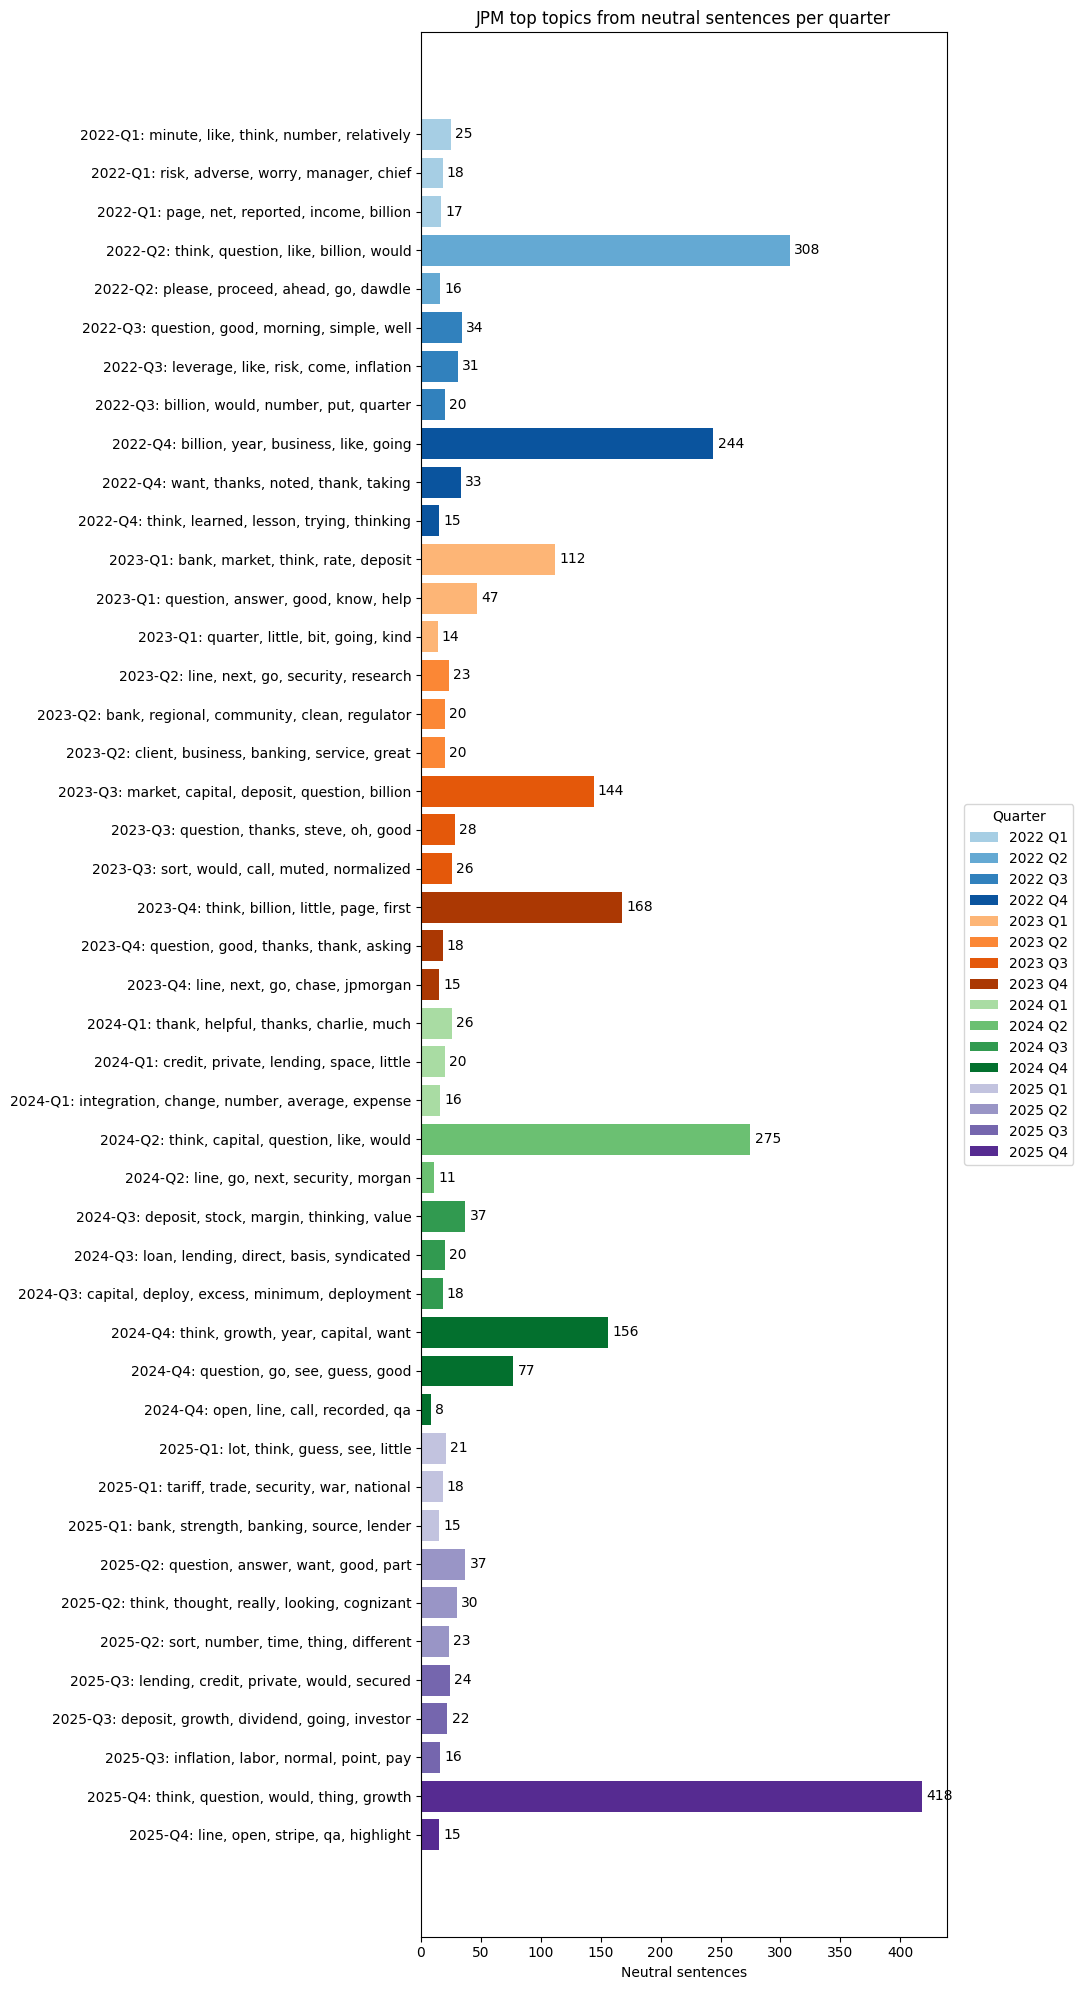

In [204]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_top_topics_single_figure(top_topics, bank=""):
    df = top_topics_neutral.copy()
    df["year"] = df["quarter"].str[:4]
    df["q"] = df["quarter"].str[-1].astype(int)

    # Chronological order, largest topic first within each quarter
    df = df.sort_values(["year", "q", "count"], ascending=[True, True, False]).reset_index(drop=True)

    base_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Reds", "Greys"]
    years = sorted(df["year"].unique())
    year_cmap = {y: plt.get_cmap(base_cmaps[i % len(base_cmaps)]) for i, y in enumerate(years)}
    # Q1 lightest -> Q4 darkest
    shade = {1: 0.35, 2: 0.52, 3: 0.69, 4: 0.86}

    colours = [year_cmap[r.year](shade[r.q]) for r in df.itertuples()]


    labels = [f"{r.quarter}: {r.keywords}" for r in df.itertuples()]

    fig, ax = plt.subplots(figsize=(11, 0.4 * len(df) + 2))
    bars = ax.barh(range(len(df)), df["count"], color=colours)
    ax.bar_label(bars, padding=3)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Neutral sentences")

    handles = [
        Patch(facecolor=year_cmap[y](shade[q]), label=f"{y} Q{q}")
        for y in years
        for q in sorted(df.loc[df["year"] == y, "q"].unique())
    ]
    ax.legend(handles=handles, title="Quarter", loc="center left",
              bbox_to_anchor=(1.02, 0.5))
    ax.set_title(f"{bank} top topics from neutral sentences per quarter".strip())
    fig.tight_layout()
    # save figure in bank folder
    plt.savefig(f"{results_folder}/neutral_sentence_topics_by_quarter_for_{bank_name}.png")

    plt.show()


plot_top_topics_single_figure(top_topics_neutral, bank=bank_name)

# Compare Models Predictions (mathematically)

### Map data to align (at end after analysis)

In [205]:
# for column "FBT_Main_Sentiment" map Positive as positive, Negative as negative and Neutral as neutral
data["FBT_Main_Sentiment"] = data["FBT_Main_Sentiment"].map({
    "Positive": "positive",
    "Negative": "negative",
    "Neutral": "neutral"
})

# for column "RBT_main_sentiment" map RBT_positive as positive, RBT_negative as negative and RBT_neutral as neutral
data["RBT_main_sentiment"] = data["RBT_main_sentiment"].map({
    "RBT_positive": "positive",
    "RBT_negative": "negative",
    "RBT_neutral": "neutral"
})

In [206]:
from sklearn.metrics import cohen_kappa_score
for c in ['main_sentiment', 'FBT_Main_Sentiment', 'RBT_main_sentiment']:
    print(c, data[c].map(type).value_counts().to_dict())
    print(data[c].head(3).tolist())

main_sentiment {<class 'str'>: 8296}
['neutral', 'neutral', 'neutral']
FBT_Main_Sentiment {<class 'str'>: 8296}
['neutral', 'neutral', 'neutral']
RBT_main_sentiment {<class 'str'>: 8296}
['positive', 'neutral', 'neutral']


In [207]:
def to_label(x):
    if isinstance(x, dict):
        x = x.get('label')
    if isinstance(x, (list, tuple)) and x:      # e.g. [{'label': ..., 'score': ...}]
        x = x[0].get('label') if isinstance(x[0], dict) else x[0]
    return str(x).lower().replace('rbt_', '').strip() if x is not None else None

cols = ['main_sentiment', 'FBT_Main_Sentiment', 'RBT_main_sentiment']
clean = data[cols].map(to_label).dropna()

from itertools import combinations
for a, b in combinations(cols, 2):
    print(a, 'vs', b, cohen_kappa_score(clean[a], clean[b]))

main_sentiment vs FBT_Main_Sentiment 0.5937600395368461
main_sentiment vs RBT_main_sentiment 0.3545644612671611
FBT_Main_Sentiment vs RBT_main_sentiment 0.4205270777755502


A score above 0.6 suggests substantial agreement from the models

# Check run times

In [208]:
# End timer and print elapsed time in minutes to 2 significant figures
end_time = time.time()
print("Elapsed time: ", round((end_time - start_time)/60, 2), "minutes")

Elapsed time:  9.31 minutes
